# Multimodal Explainable AI for Early Diabetes Prediction
## Full Pipeline — Phases 1–5

| Phase | Description |
|---|---|
| 1 | Data loading, preprocessing, feature engineering |
| 2 | Synthetic clinical notes + ClinicalBERT embeddings |
| 3 | Baseline models + Early/Late Fusion + evaluation |
| 4 | SHAP explainability + LLM recommendations |
| 5 | Publication-ready figures and tables |

> **Dataset:** Diabetes 130-US Hospitals 1999–2008 (UCI, ID=296)  
> **Reproducibility:** `RANDOM_SEED = 42` throughout.

---
# Phase 1 — Data Loading & Preprocessing

## 0. Install

In [1]:
!pip install ucimlrepo imbalanced-learn groq transformers torch tqdm umap-learn shap xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.2 MB/s eta 0:00:00


## 1. Imports & global config

All libraries for the entire pipeline imported here once.

In [2]:
import os, json, time, warnings, pickle, shutil, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from groq import Groq, RateLimitError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
import shap

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#F8F9FB",
    "axes.grid":True,"grid.alpha":0.4,
    "axes.spines.top":False,"axes.spines.right":False,"font.size":11,
})
PALETTE = {
    "neg":"#4A90D9","pos":"#E05C5C","neu":"#7F77DD",
    "lr":"#4A90D9","rf":"#56B87A","xgb":"#E0AA00",
    "early":"#E05C5C","late":"#9B59B6","tab":"#7F77DD",
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("data", exist_ok=True)
os.makedirs("data/models", exist_ok=True)
os.makedirs("data/figures", exist_ok=True)
os.makedirs("data/paper", exist_ok=True)
print(f"Ready. RANDOM_SEED={RANDOM_SEED} | device={device}")

Ready. RANDOM_SEED=42 | device=cpu


## 2. Google Drive — mount & restore

Run at the start of **every new Colab session** to restore saved artefacts.

In [3]:
from google.colab import drive, userdata
drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/diabetes_project/data"
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/models", exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/paper", exist_ok=True)

RESTORE_FILES = [
    "scaler.pkl","feature_names.json","diabetes_clean.parquet",
    "X_train.npy","X_val.npy","X_test.npy",
    "y_train.npy","y_val.npy","y_test.npy",
    "text_embeddings.npy","synthetic_notes_final.csv",
    "synthetic_notes.csv","notes_checkpoint.csv",
    "results_summary.csv","shap_values_xgb.npy",
    "recommendations_sample.csv",
]
for fname in RESTORE_FILES:
    src, dst = f"{DRIVE_DIR}/{fname}", f"data/{fname}"
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst); print(f"  Restored: {fname}")

for mname in ["xgboost.json","logistic_regression.pkl",
              "random_forest.pkl","early_fusion.pt","late_fusion.pt"]:
    src, dst = f"{DRIVE_DIR}/models/{mname}", f"data/models/{mname}"
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst); print(f"Restored model: {mname}")

print("Restore complete.")

Mounted at /content/drive
  Restored: scaler.pkl
  Restored: feature_names.json
  Restored: diabetes_clean.parquet
  Restored: X_train.npy
  Restored: X_val.npy
  Restored: X_test.npy
  Restored: y_train.npy
  Restored: y_val.npy
  Restored: y_test.npy
  Restored: text_embeddings.npy
  Restored: synthetic_notes_final.csv
  Restored: synthetic_notes.csv
  Restored: notes_checkpoint.csv
  Restored: results_summary.csv
  Restored: shap_values_xgb.npy
  Restored: recommendations_sample.csv
Restored model: xgboost.json
Restored model: logistic_regression.pkl
Restored model: random_forest.pkl
Restored model: early_fusion.pt
Restored model: late_fusion.pt
Restore complete.


## 3. Load dataset

101,766 hospital encounters, 130 US hospitals, 1999–2008.

In [4]:
raw = fetch_ucirepo(id=296)
X = raw.data.features.copy()
y = raw.data.targets.copy()
df = pd.concat([X, y], axis=1)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
df.head(3)

Shape: 101,766 rows x 48 columns
Memory: 197.1 MB


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO


## 4. Define binary target

- **1** = readmitted <30 days (high risk)
- **0** = >30 days or NO (low risk)

Reference: Strack et al. (2014)

In [5]:
print("Original distribution:")
print(df["readmitted"].value_counts())

df["target"] = (df["readmitted"] == "<30").astype(int)
n_pos = df["target"].sum()
n_neg = len(df) - n_pos
ratio = n_pos / len(df)
print(f"\nHigh risk (1): {n_pos:,} ({ratio:.1%})")
print(f"Low  risk (0): {n_neg:,} ({1-ratio:.1%})")
print("NOTE: ~11% positive — addressed with SMOTE on train only")

Original distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

High risk (1): 11,357 (11.2%)
Low  risk (0): 90,409 (88.8%)
NOTE: ~11% positive — addressed with SMOTE on train only


## 5. Feature selection

Four semantic groups (used later for SHAP interpretation).

In [6]:
DEMOGRAPHIC = [
    "race","gender","age","admission_type_id",
    "discharge_disposition_id","admission_source_id","time_in_hospital",
]
CLINICAL = [
    "num_lab_procedures","num_procedures","num_medications",
    "number_outpatient","number_emergency","number_inpatient","number_diagnoses",
]
DIABETES_SPECIFIC = [
    "max_glu_serum","A1Cresult","insulin","metformin",
    "glipizide","glyburide","pioglitazone","rosiglitazone",
    "change","diabetesMed",
]
DIAGNOSIS = ["diag_1","diag_2","diag_3"]

SELECTED_FEATURES = DEMOGRAPHIC + CLINICAL + DIABETES_SPECIFIC + DIAGNOSIS
df_sel = df[SELECTED_FEATURES + ["target"]].copy()
print(f"Selected {len(SELECTED_FEATURES)} / {X.shape[1]} features")

Selected 27 / 47 features


## 6. Missing values

Dataset encodes missing as `"?"`. Strategy: drop >40%, median/mode impute rest.

In [7]:
df_sel.replace("?", np.nan, inplace=True)

missing = df_sel.isnull().sum()
missing_pct = (missing/len(df_sel)*100).round(2)
missing_df = pd.DataFrame({"count":missing,"pct":missing_pct})
missing_df = missing_df[missing_df["count"]>0].sort_values("pct",ascending=False)
print(missing_df.to_string())

DROP_THRESHOLD = 40.0
cols_to_drop = missing_df[missing_df["pct"]>DROP_THRESHOLD].index.tolist()
if cols_to_drop:
    print(f"Dropping: {cols_to_drop}")
    df_sel.drop(columns=cols_to_drop, inplace=True)

NUM_COLS = [c for c in df_sel.select_dtypes(include=["int64","float64"]).columns if c!="target"]
CAT_COLS = [c for c in df_sel.select_dtypes(include="object").columns if c!="target"]
for col in NUM_COLS:
    if df_sel[col].isnull().any(): df_sel[col].fillna(df_sel[col].median(), inplace=True)
for col in CAT_COLS:
    if df_sel[col].isnull().any(): df_sel[col].fillna(df_sel[col].mode()[0], inplace=True)

print(f"Remaining missing: {df_sel.isnull().sum().sum()}")

               count    pct
max_glu_serum  96420  94.75
A1Cresult      84748  83.28
race            2273   2.23
diag_3          1423   1.40
diag_2           358   0.35
diag_1            21   0.02
Dropping: ['max_glu_serum', 'A1Cresult']
Remaining missing: 0


## 7. ICD-9 grouping

700+ codes → 9 clinical categories (Strack et al., 2014, Table 2).

In [8]:
def icd9_to_category(code):
    if pd.isna(code): return "Other"
    code = str(code)
    if code.startswith("E") or code.startswith("V"): return "Other"
    try: c = float(code)
    except ValueError: return "Other"
    if   390<=c<=459 or c==785: return "Circulatory"
    elif 460<=c<=519 or c==786: return "Respiratory"
    elif 520<=c<=579 or c==787: return "Digestive"
    elif c==250: return "Diabetes"
    elif 800<=c<=999: return "Injury"
    elif 710<=c<=739: return "Musculoskeletal"
    elif 580<=c<=629 or c==788: return "Genitourinary"
    elif 140<=c<=239: return "Neoplasms"
    else: return "Other"

for col in ["diag_1","diag_2","diag_3"]:
    if col in df_sel.columns:
        df_sel[col] = df_sel[col].apply(icd9_to_category)
print("ICD-9 grouping complete.")

ICD-9 grouping complete.


## 8. Encoding

In [9]:
AGE_MAP = {"[0-10)":0,"[10-20)":1,"[20-30)":2,"[30-40)":3,"[40-50)":4,
           "[50-60)":5,"[60-70)":6,"[70-80)":7,"[80-90)":8,"[90-100)":9}
if "age" in df_sel.columns: df_sel["age"] = df_sel["age"].map(AGE_MAP)
if "gender" in df_sel.columns:
    df_sel["gender"] = df_sel["gender"].map({"Male":1,"Female":0,"Unknown/Invalid":np.nan})
    df_sel["gender"].fillna(df_sel["gender"].mode()[0], inplace=True)
if "A1Cresult"     in df_sel.columns: df_sel["A1Cresult"]     = df_sel["A1Cresult"].map({"None":0,"Norm":1,">7":2,">8":3}).fillna(0).astype(int)
if "max_glu_serum" in df_sel.columns: df_sel["max_glu_serum"] = df_sel["max_glu_serum"].map({"None":0,"Norm":1,">200":2,">300":3}).fillna(0).astype(int)

MED_MAP = {"No":0,"Steady":1,"Down":2,"Up":2}
for col in ["metformin","glipizide","glyburide","pioglitazone","rosiglitazone","insulin"]:
    if col in df_sel.columns: df_sel[col] = df_sel[col].map(MED_MAP).fillna(0).astype(int)
if "change"      in df_sel.columns: df_sel["change"]      = df_sel["change"].map({"No":0,"Ch":1}).fillna(0).astype(int)
if "diabetesMed" in df_sel.columns: df_sel["diabetesMed"] = df_sel["diabetesMed"].map({"No":0,"Yes":1}).fillna(0).astype(int)

remaining_cat = [c for c in df_sel.select_dtypes(include="object").columns if c!="target"]
if remaining_cat: df_sel = pd.get_dummies(df_sel, columns=remaining_cat, drop_first=True)

bool_cols = df_sel.select_dtypes(include="bool").columns
if len(bool_cols): df_sel[bool_cols] = df_sel[bool_cols].astype(int)

before = len(df_sel)
df_sel.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before-len(df_sel)}")
print(f"Shape: {df_sel.shape}")

Duplicates removed: 3
Shape: (101763, 50)


## 9. EDA — distributions & correlation

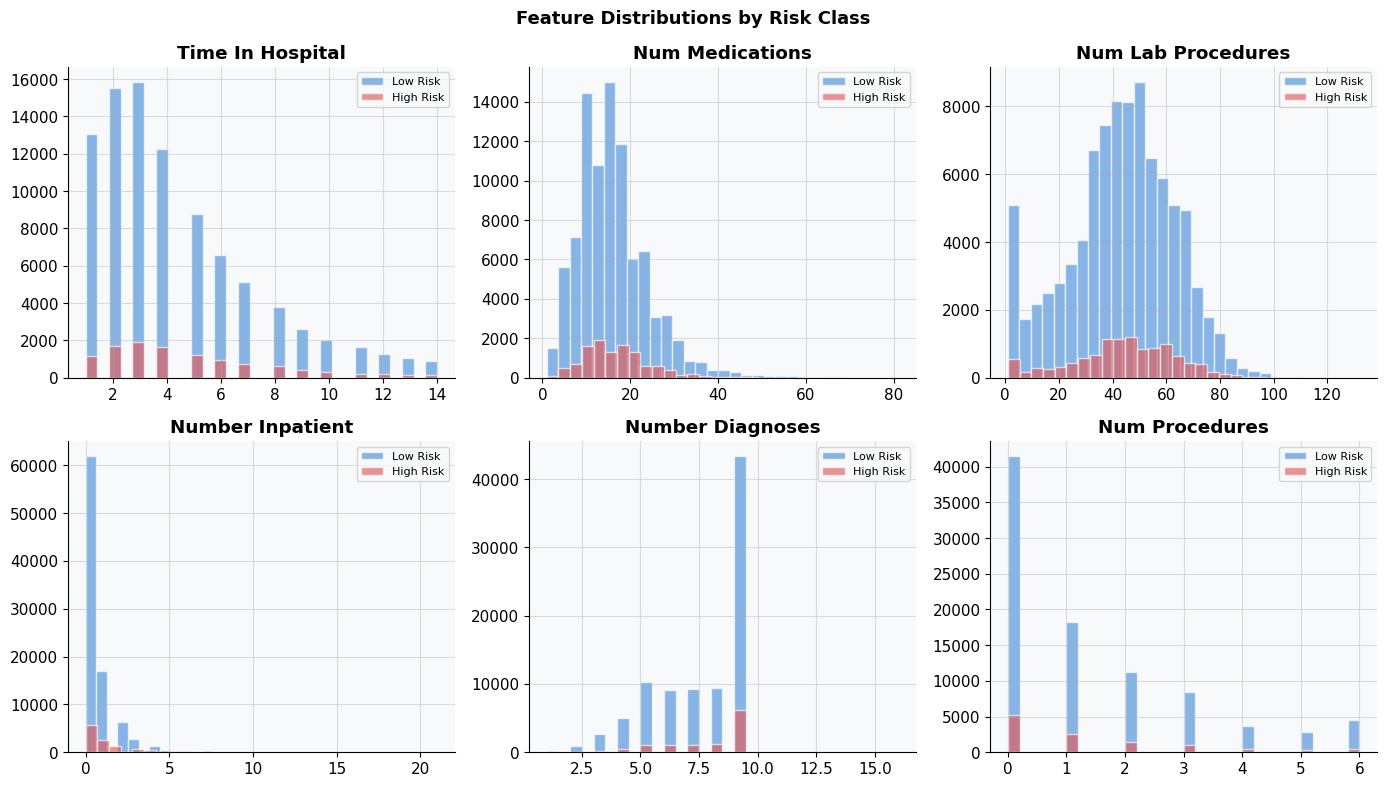

In [10]:
KEY_NUM = [c for c in ["time_in_hospital","num_medications","num_lab_procedures",
                        "number_inpatient","number_diagnoses","num_procedures"] if c in df_sel.columns]
fig, axes = plt.subplots(2,3,figsize=(14,8)); axes=axes.flatten()
for i,col in enumerate(KEY_NUM):
    for lbl,clr,nm in [(0,PALETTE["neg"],"Low Risk"),(1,PALETTE["pos"],"High Risk")]:
        axes[i].hist(df_sel[df_sel["target"]==lbl][col],bins=30,alpha=0.65,
                     color=clr,label=nm,edgecolor="white")
    axes[i].set_title(col.replace("_"," ").title(),fontweight="bold")
    axes[i].legend(fontsize=8)
for j in range(len(KEY_NUM),len(axes)): axes[j].set_visible(False)
plt.suptitle("Feature Distributions by Risk Class",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

## 10. Train / Val / Test split

>Split before SMOTE — prevents data leakage.

In [11]:
FEATURE_COLS = [c for c in df_sel.columns if c!="target"]
X_all = df_sel[FEATURE_COLS].values.astype(np.float32)
y_all = df_sel["target"].values

X_train,X_temp,y_train,y_temp = train_test_split(
    X_all,y_all,test_size=0.30,random_state=RANDOM_SEED,stratify=y_all)
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=RANDOM_SEED,stratify=y_temp)

for nm,X_,y_ in [("Train",X_train,y_train),("Val",X_val,y_val),("Test",X_test,y_test)]:
    print(f"{nm:5s}: {len(X_):>7,}  pos={y_.mean():.1%}")

Train:  71,234  pos=11.2%
Val  :  15,264  pos=11.2%
Test :  15,265  pos=11.2%


## 11. SMOTE — train only

In [12]:
before = np.bincount(y_train)
smote  = SMOTE(random_state=RANDOM_SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
after  = np.bincount(y_train_bal)
print(f"Before: {before}  After: {after}")

Before: [63284  7950]  After: [63284 63284]


## 12. Feature scaling

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print(f"Train shape: {X_train_scaled.shape}")

Train shape: (126568, 49)


## 13. Save Phase 1 artefacts

In [14]:
df_sel = df_sel.reset_index(drop=True)
df_sel.to_parquet("data/diabetes_clean.parquet", index=True)

np.save("data/X_train.npy", X_train_scaled)
np.save("data/X_val.npy", X_val_scaled)
np.save("data/X_test.npy", X_test_scaled)
np.save("data/y_train.npy", y_train_bal)
np.save("data/y_val.npy", y_val)
np.save("data/y_test.npy", y_test)

with open("data/feature_names.json","w") as f: json.dump(FEATURE_COLS,f,indent=2)
with open("data/scaler.pkl","wb") as f: pickle.dump(scaler,f)

for fname in ["diabetes_clean.parquet","X_train.npy","X_val.npy","X_test.npy",
              "y_train.npy","y_val.npy","y_test.npy","feature_names.json","scaler.pkl"]:
    shutil.copy2(f"data/{fname}", f"{DRIVE_DIR}/{fname}")

print("Phase 1 saved and synced to Drive.")

Phase 1 saved and synced to Drive.


---
# Phase 2 — Synthetic Clinical Notes & ClinicalBERT Embeddings

## Rationale

Real notes unavailable (privacy). Synthetic feature-conditioned notes validated
as NLP supplement. Reference: Alshaikhdeeb et al., 2025

## 14. Groq API client

In [16]:
client = Groq(api_key=userdata.get("GROQ_API_key"))
print("Groq client initialised.")

Groq client initialised.


## 15. Sampling strategy

> `original_index` stores row position in `df_clean` (0..~100k).

In [17]:
N_SAMPLE = 10000

df_clean_loaded = pd.read_parquet("data/diabetes_clean.parquet").reset_index(drop=True)

df_sampled = df_clean_loaded.sample(
    n=min(N_SAMPLE, len(df_clean_loaded)),
    random_state=RANDOM_SEED
).copy()

df_sampled["original_index"] = df_sampled.index
df_sampled = df_sampled.reset_index(drop=True)

print(f"Sampled: {len(df_sampled):,}")
print(f"original_index range: {df_sampled['original_index'].min()} — {df_sampled['original_index'].max()}")
print(f"Class balance: {df_sampled['target'].value_counts().to_dict()}")
print(f"Positive rate: {df_sampled['target'].mean():.1%}")

assert df_sampled["original_index"].max() > 1000, "original_index wrong!"
assert abs(df_sampled["target"].mean() - 0.112) < 0.05, "Positive rate wrong!"
print("CHECK: PASS")

Sampled: 10,000
original_index range: 23 — 101750
Class balance: {0: 8873, 1: 1127}
Positive rate: 11.3%
CHECK: PASS


## 16. Prompt engineering — token-efficient

In [18]:
SYSTEM_PROMPT = (
    "Physician writing 2-3 sentence EHR note. "
    "Plain prose, no headers. Medical style. No names or dates."
)
AGE_DECODE = {0:"0-10",1:"10-20",2:"20-30",3:"30-40",4:"40-50",
              5:"50-60",6:"60-70",7:"70-80",8:"80-90",9:"90-100"}
A1C_DECODE = {0:"NA",1:"nl",2:">7",3:">8"}
GLU_DECODE = {0:"NA",1:"nl",2:">200",3:">300"}
MED_DECODE = {0:"no",1:"stable",2:"adjusted"}
GENDER_DECODE = {1:"M",0:"F"}

def build_user_prompt(row):
    def si(k,d=0):
        try: return int(row.get(k,d))
        except: return d
    return (
        "EHR note:\n"
        f"Pt:{GENDER_DECODE.get(si('gender'),'?')} age {AGE_DECODE.get(si('age',5),'?')}y\n"
        f"LOS:{si('time_in_hospital')}d dx:{si('number_diagnoses')} "
        f"labs:{si('num_lab_procedures')} meds:{si('num_medications')}\n"
        f"A1c:{A1C_DECODE.get(si('A1Cresult'),'NA')} "
        f"glu:{GLU_DECODE.get(si('max_glu_serum'),'NA')} "
        f"insulin:{MED_DECODE.get(si('insulin'),'no')} "
        f"metformin:{MED_DECODE.get(si('metformin'),'no')} "
        f"changed:{'yes' if si('change')==1 else 'no'}\n"
        f"prior_inpat:{si('number_inpatient')} prior_ED:{si('number_emergency')}\n"
        f"Risk:{'HIGH-readmission' if int(row['target'])==1 else 'LOW-readmission'}\n"
        "Note:"
    )
print("Prompt builder ready.")

Prompt builder ready.


## 17. API dry run

In [19]:
test_msg = client.chat.completions.create(
    model="llama-3.1-8b-instant", max_tokens=80, temperature=0.4,
    messages=[{"role":"system","content":SYSTEM_PROMPT},
              {"role":"user","content":build_user_prompt(df_sampled.iloc[0])}])
print(test_msg.choices[0].message.content)
print(f"Tokens: {test_msg.usage.total_tokens}")

The patient, a 70-80 year old male, has been hospitalized for 4 days with a complex medical history and multiple comorbidities. His blood glucose and A1c levels are not available, but his insulin and metformin regimens remain stable. Despite recent changes to his treatment plan, his high risk for readmission persists due to a history of previous inpatient stays and
Tokens: 206


## 18. Batch generation — parallel with Drive checkpoint

In [20]:
import concurrent.futures
import threading

DRIVE_CHECKPOINT = f"{DRIVE_DIR}/notes_checkpoint.csv"
DRIVE_NOTES = f"{DRIVE_DIR}/synthetic_notes.csv"
LOCAL_CHECKPOINT = "data/notes_checkpoint.csv"
NOTES_PATH = "data/synthetic_notes.csv"
CHECKPOINT_EVERY = 50
BATCH_SIZE = 3
DELAY_BETWEEN = 2.5


if os.path.exists(DRIVE_CHECKPOINT):
    shutil.copy2(DRIVE_CHECKPOINT, LOCAL_CHECKPOINT)
    print("Checkpoint restored from Drive.")
elif os.path.exists(LOCAL_CHECKPOINT):
    print("Using local checkpoint.")
else:
    print("Starting fresh.")

if os.path.exists(LOCAL_CHECKPOINT):
    checkpoint_df = pd.read_csv(LOCAL_CHECKPOINT)
    successful_df = checkpoint_df[checkpoint_df["note"] != "[GENERATION_FAILED]"]
    done_ids  = set(successful_df["original_index"].tolist())
    notes     = successful_df["note"].tolist()
    processed = successful_df["original_index"].tolist()
    targets   = successful_df["target"].tolist()
    print(f"Resuming from {len(done_ids):,} successful notes.")
    print(f"Failed previously: {len(checkpoint_df)-len(done_ids):,}")
else:
    notes, processed, targets, done_ids = [], [], [], set()

lock = threading.Lock()

def save_and_sync(processed, targets, notes, is_final=False):
    lpath = NOTES_PATH if is_final else LOCAL_CHECKPOINT
    dpath = DRIVE_NOTES if is_final else DRIVE_CHECKPOINT
    df_out = pd.DataFrame({"original_index":processed,"target":targets,"note":notes})
    if is_final:
        df_out = df_out[df_out["note"]!="[GENERATION_FAILED]"].reset_index(drop=True)
    df_out.to_csv(lpath, index=False)
    try: shutil.copy2(lpath, dpath)
    except Exception as e: print(f"  Drive sync failed: {e}")
    print(f"  Saved {'final' if is_final else 'checkpoint'}: {len(df_out)} rows")
    return df_out

def generate_single(row_tuple):
    orig_idx, target_val, row = row_tuple
    for attempt in range(5):
        try:
            resp = client.chat.completions.create(
                model="llama-3.1-8b-instant", max_tokens=60, temperature=0.4,
                messages=[{"role":"system","content":SYSTEM_PROMPT},
                          {"role":"user","content":build_user_prompt(row)}])
            return (orig_idx, target_val, resp.choices[0].message.content.strip())
        except RateLimitError:
            wait = 60*(attempt+1)
            tqdm.write(f"  RateLimit — waiting {wait}s...")
            time.sleep(wait)
        except Exception: time.sleep(2)
    return (orig_idx, target_val, "[GENERATION_FAILED]")

to_process = df_sampled[~df_sampled["original_index"].isin(done_ids)]
print(f"Left to generate: {len(to_process):,}")

tasks = [(int(row["original_index"]), int(row["target"]), row)
         for _, row in to_process.iterrows()]

n_completed = 0

with tqdm(total=len(tasks), desc="Generating") as pbar:
    for batch_start in range(0, len(tasks), BATCH_SIZE):
        batch = tasks[batch_start:batch_start+BATCH_SIZE]
        with concurrent.futures.ThreadPoolExecutor(max_workers=BATCH_SIZE) as executor:
            results = list(executor.map(generate_single, batch))
        with lock:
            for orig_idx, target_val, note in results:
                notes.append(note); processed.append(orig_idx)
                targets.append(target_val); done_ids.add(orig_idx)
                n_completed += 1
            if n_completed % CHECKPOINT_EVERY == 0:
                save_and_sync(processed, targets, notes, is_final=False)
                failed_so_far = sum(1 for n in notes if n=="[GENERATION_FAILED]")
                tqdm.write(f"  [{n_completed}/{len(tasks)}] failed={failed_so_far}")
        pbar.update(len(batch))
        time.sleep(DELAY_BETWEEN * BATCH_SIZE)

notes_df = save_and_sync(processed, targets, notes, is_final=True)
failed   = sum(1 for n in notes if n=="[GENERATION_FAILED]")
print(f"Done. {len(notes_df):,} notes saved. Failed: {failed}")
print(f"Positive rate: {notes_df['target'].mean():.1%}  (expected ~11%)")

Checkpoint restored from Drive.
Resuming from 10,000 successful notes.
Failed previously: 0
Left to generate: 0


Generating: 0it [00:00, ?it/s]

  Saved final: 10000 rows
Done. 10,000 notes saved. Failed: 0
Positive rate: 11.3%  (expected ~11%)


## 19. Build synthetic_notes_final.csv

Works from checkpoint even if NOTES_PATH doesn't exist yet.

In [21]:
LOCAL_CHECKPOINT = "data/notes_checkpoint.csv"
DRIVE_CHECKPOINT = f"{DRIVE_DIR}/notes_checkpoint.csv"

if not os.path.exists(LOCAL_CHECKPOINT):
    if os.path.exists(DRIVE_CHECKPOINT):
        shutil.copy2(DRIVE_CHECKPOINT, LOCAL_CHECKPOINT)
        print("Checkpoint restored from Drive.")
    else:
        raise FileNotFoundError("No checkpoint found anywhere!")
else:
    print("Using local checkpoint.")

checkpoint_df = pd.read_csv(LOCAL_CHECKPOINT)
notes_df = checkpoint_df[checkpoint_df["note"]!="[GENERATION_FAILED]"].reset_index(drop=True)
notes_df["embedding_idx"] = range(len(notes_df))
notes_df.to_csv("data/synthetic_notes_final.csv", index=False)
try: shutil.copy2("data/synthetic_notes_final.csv", f"{DRIVE_DIR}/synthetic_notes_final.csv")
except: pass

print(f"Checkpoint total  : {len(checkpoint_df):,}")
print(f"Failed (excluded) : {(checkpoint_df['note']=='[GENERATION_FAILED]').sum():,}")
print(f"Successful (used) : {len(notes_df):,}")
print(f"Positive rate     : {notes_df['target'].mean():.1%}")
print(f"original_index    : {notes_df['original_index'].min()} — {notes_df['original_index'].max()}")
assert notes_df["original_index"].max() > 1000, "original_index wrong!"
print("CHECK: PASS")

Using local checkpoint.
Checkpoint total  : 10,000
Failed (excluded) : 0
Successful (used) : 10,000
Positive rate     : 11.3%
original_index    : 23 — 101750
CHECK: PASS


## 20. Quality validation

In [22]:
notes_df["word_count"] = notes_df["note"].str.split().str.len()
notes_df["has_any_keyword"] = notes_df["note"].apply(
    lambda t: bool(re.search(
        r"\b(glucose|insulin|diabetes|glycemic|HbA1c|A1c|hyperglycemia|metformin)\b",t,re.I)))
hit_rate = notes_df["has_any_keyword"].mean()
N_DIV    = min(300,len(notes_df))
sample_t = notes_df["note"].sample(N_DIV,random_state=RANDOM_SEED).tolist()
tfidf_m  = TfidfVectorizer(max_features=3000,stop_words="english").fit_transform(sample_t)
sim_vals = cosine_similarity(tfidf_m)[np.triu_indices(N_DIV,k=1)]
mean_sim = sim_vals.mean()

print(f"Mean words : {notes_df['word_count'].mean():.1f}  ({'PASS' if notes_df['word_count'].mean()>=20 else 'FAIL'})")
print(f"Keyword hit: {hit_rate:.1%}  ({'PASS' if hit_rate>=0.8 else 'FAIL'})")
print(f"TF-IDF sim : {mean_sim:.4f}  ({'PASS' if mean_sim<0.5 else 'WARN'})")

Mean words : 46.9  (PASS)
Keyword hit: 95.9%  (PASS)
TF-IDF sim : 0.1894  (PASS)


## 21. Bio+ClinicalBERT embeddings

Cached — skips computation if file exists with correct size.

In [23]:
LOCAL_EMB = "data/text_embeddings.npy"
DRIVE_EMB = f"{DRIVE_DIR}/text_embeddings.npy"

loaded = False
for src in [LOCAL_EMB, DRIVE_EMB]:
    if os.path.exists(src):
        tmp = np.load(src)
        if tmp.shape[0] == len(notes_df):
            if src == DRIVE_EMB: shutil.copy2(src, LOCAL_EMB)
            text_embeddings = tmp
            print(f"Loaded from cache: {text_embeddings.shape}")
            loaded = True
            break
        else:
            print(f"Cache size mismatch ({tmp.shape[0]} vs {len(notes_df)}) — recomputing")
            os.remove(src)

if not loaded:
    MODEL_NAME     = "emilyalsentzer/Bio_ClinicalBERT"
    print(f"Loading {MODEL_NAME} ...")
    bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    bert_model_emb = AutoModel.from_pretrained(MODEL_NAME).to(device)
    bert_model_emb.eval()

    def encode_notes_batch(texts, batch_size=32):
        all_vecs = []
        for start in tqdm(range(0,len(texts),batch_size),desc="Encoding"):
            batch   = texts[start:start+batch_size]
            encoded = bert_tokenizer(batch,padding=True,truncation=True,
                                     max_length=128,return_tensors="pt")
            encoded = {k:v.to(device) for k,v in encoded.items()}
            with torch.no_grad():
                out = bert_model_emb(**encoded)
            all_vecs.append(out.last_hidden_state[:,0,:].cpu().numpy())
        vecs = np.vstack(all_vecs)
        return vecs / np.linalg.norm(vecs,axis=1,keepdims=True)

    text_embeddings = encode_notes_batch(notes_df["note"].tolist())
    np.save(LOCAL_EMB, text_embeddings.astype(np.float32))
    shutil.copy2(LOCAL_EMB, DRIVE_EMB)
    print(f"Computed and saved: {text_embeddings.shape}")

print(f"Shape : {text_embeddings.shape}")
print(f"Norm : {np.linalg.norm(text_embeddings[0]):.6f}  (should be ~1.0)")
assert text_embeddings.shape[0]==len(notes_df), "Shape mismatch!"
print("CHECK: PASS")

Loaded from cache: (10000, 768)
Shape : (10000, 768)
Norm : 1.000000  (should be ~1.0)
CHECK: PASS


---
# Phase 3 — Models, Fusion & Evaluation

## 22. Load Phase 1 & 2 artefacts

In [24]:
X_train = np.load("data/X_train.npy"); X_val = np.load("data/X_val.npy")
X_test = np.load("data/X_test.npy")
y_train = np.load("data/y_train.npy"); y_val = np.load("data/y_val.npy")
y_test = np.load("data/y_test.npy")
text_embeddings = np.load("data/text_embeddings.npy")
notes_df = pd.read_csv("data/synthetic_notes_final.csv")
with open("data/feature_names.json") as f: FEATURE_COLS = json.load(f)
with open("data/scaler.pkl","rb") as f: scaler = pickle.load(f)
TAB_DIM=X_train.shape[1]; TEXT_DIM=text_embeddings.shape[1]
print(f"TAB_DIM={TAB_DIM}  TEXT_DIM={TEXT_DIM}")
print(f"Train={X_train.shape} Val={X_val.shape} Test={X_test.shape}")

TAB_DIM=49  TEXT_DIM=768
Train=(126568, 49) Val=(15264, 49) Test=(15265, 49)


## 23. Aligned multimodal dataset

In [25]:
df_clean = pd.read_parquet("data/diabetes_clean.parquet")
common_indices = sorted(
    set(notes_df["original_index"]).intersection(set(df_clean.index)))

print(f"Patients with embeddings: {len(notes_df):,}")
print(f"Common with df_clean: {len(common_indices):,}")

emb_map    = notes_df.set_index("original_index")["embedding_idx"].to_dict()
df_mm      = df_clean.loc[common_indices].copy().sort_index()
X_tab_all  = scaler.transform(df_mm[FEATURE_COLS].values.astype(np.float32))
y_all_mm   = df_mm["target"].values
X_text_all = np.array([text_embeddings[emb_map[idx]] for idx in df_mm.index])

print(f"\nMultimodal pool: {len(y_all_mm):,} patients")
print(f"Positive rate: {y_all_mm.mean():.1%}")
assert len(np.unique(y_all_mm))==2, "Only one class!"

mm_idx = np.arange(len(df_mm))
idx_train_mm, idx_temp_mm = train_test_split(
    mm_idx, test_size=0.30, random_state=RANDOM_SEED, stratify=y_all_mm)
idx_val_mm, idx_test_mm = train_test_split(
    idx_temp_mm, test_size=0.50, random_state=RANDOM_SEED,
    stratify=y_all_mm[idx_temp_mm])

X_train_tab_mm = X_tab_all[idx_train_mm]
X_train_text   = X_text_all[idx_train_mm]
y_train_mm     = y_all_mm[idx_train_mm]

X_val_tab_mm   = X_tab_all[idx_val_mm]
X_val_text     = X_text_all[idx_val_mm]
y_val_mm       = y_all_mm[idx_val_mm]

X_test_tab_mm  = X_tab_all[idx_test_mm]
X_test_text    = X_text_all[idx_test_mm]
y_test_mm      = y_all_mm[idx_test_mm]

print(f"\nBefore SMOTE:")
print(f"  Train: {len(y_train_mm):,}  pos={y_train_mm.mean():.1%}")
print(f"  Val  : {len(y_val_mm):,}  pos={y_val_mm.mean():.1%}")
print(f"  Test : {len(y_test_mm):,}  pos={y_test_mm.mean():.1%}")


if y_train_mm.mean() < 0.30:
    print(f"\nApplying SMOTE (pos={y_train_mm.mean():.1%})...")
    X_combined = np.hstack([X_train_tab_mm, X_train_text])
    X_combined_bal, y_train_mm = SMOTE(random_state=RANDOM_SEED).fit_resample(
        X_combined, y_train_mm)
    tab_dim        = X_train_tab_mm.shape[1]
    X_train_tab_mm = X_combined_bal[:, :tab_dim]
    X_train_text   = X_combined_bal[:, tab_dim:]
    print(f"After SMOTE: {len(y_train_mm):,}  pos={y_train_mm.mean():.1%}")
else:
    print("SMOTE not needed — already balanced")

print(f"\nFinal splits:")
print(f"  Train: {len(y_train_mm):,}  pos={y_train_mm.mean():.1%}")
print(f"  Val  : {len(y_val_mm):,}  pos={y_val_mm.mean():.1%}")
print(f"  Test : {len(y_test_mm):,}  pos={y_test_mm.mean():.1%}")

np.save("data/mm_idx_train.npy", idx_train_mm)
np.save("data/mm_idx_val.npy",   idx_val_mm)
np.save("data/mm_idx_test.npy",  idx_test_mm)

Patients with embeddings: 10,000
Common with df_clean: 10,000

Multimodal pool: 10,000 patients
Positive rate: 11.3%

Before SMOTE:
  Train: 7,000  pos=11.3%
  Val  : 1,500  pos=11.3%
  Test : 1,500  pos=11.3%

Applying SMOTE (pos=11.3%)...
After SMOTE: 12,422  pos=50.0%

Final splits:
  Train: 12,422  pos=50.0%
  Val  : 1,500  pos=11.3%
  Test : 1,500  pos=11.3%


In [26]:
df_full   = pd.read_parquet("data/diabetes_clean.parquet")
df_subset = df_clean.loc[common_indices]

print("Representativeness check:")
print(f"  Full dataset positive rate   : {df_full['target'].mean():.1%}")
print(f"  Aligned subset positive rate : {df_subset['target'].mean():.1%}")

for feat in ["time_in_hospital","num_medications","number_inpatient","A1Cresult"]:
    if feat in df_full.columns:
        full_mean   = df_full[feat].mean()
        subset_mean = df_subset[feat].mean()
        diff = abs(full_mean - subset_mean) / full_mean * 100
        print(f"  {feat:<25}: full={full_mean:.2f}  subset={subset_mean:.2f}  diff={diff:.1f}%")

Representativeness check:
  Full dataset positive rate   : 11.2%
  Aligned subset positive rate : 11.3%
  time_in_hospital         : full=4.40  subset=4.38  diff=0.5%
  num_medications          : full=16.02  subset=16.09  diff=0.4%
  number_inpatient         : full=0.64  subset=0.66  diff=3.2%


## 24. Evaluation helper & threshold finder

In [27]:
def find_best_threshold(y_true, y_prob):
    """Find threshold maximising F1 on validation set."""
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.05, 0.95, 0.01):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(float(best_t), 2)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc_roc":   round(roc_auc_score(y_true, y_prob), 4),
        "pr_auc":    round(average_precision_score(y_true, y_prob), 4),
        "f1":        round(f1_score(y_true, y_pred, zero_division=0), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
    }

test_results = {}
print("Metrics helper ready.")

Metrics helper ready.


## 25. Logistic Regression

In [28]:
print("Training Logistic Regression ...")
lr_model = LogisticRegression(C=0.1,max_iter=1000,random_state=RANDOM_SEED,n_jobs=-1)
lr_model.fit(X_train,y_train)
print(f"Val AUC: {roc_auc_score(y_val,lr_model.predict_proba(X_val)[:,1]):.4f}")
with open("data/models/logistic_regression.pkl","wb") as f: pickle.dump(lr_model,f)
shutil.copy2("data/models/logistic_regression.pkl",f"{DRIVE_DIR}/models/logistic_regression.pkl")

Training Logistic Regression ...
Val AUC: 0.6331


'/content/drive/MyDrive/diabetes_project/data/models/logistic_regression.pkl'

## 26. Random Forest

In [29]:
print("Training Random Forest ...")
rf_model = RandomForestClassifier(n_estimators=200,max_depth=12,min_samples_leaf=5,
                                   random_state=RANDOM_SEED,n_jobs=-1)
rf_model.fit(X_train,y_train)
print(f"Val AUC: {roc_auc_score(y_val,rf_model.predict_proba(X_val)[:,1]):.4f}")
with open("data/models/random_forest.pkl","wb") as f: pickle.dump(rf_model,f)
shutil.copy2("data/models/random_forest.pkl",f"{DRIVE_DIR}/models/random_forest.pkl")

Training Random Forest ...
Val AUC: 0.6378


'/content/drive/MyDrive/diabetes_project/data/models/random_forest.pkl'

## 27. XGBoost

In [30]:
print("Training XGBoost ...")
pos_weight = (y_train==0).sum()/max((y_train==1).sum(),1)
xgb_model  = XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=6,
                             subsample=0.8,colsample_bytree=0.8,
                             reg_alpha=0.1,reg_lambda=1.0,
                             scale_pos_weight=pos_weight,eval_metric="auc",
                             random_state=RANDOM_SEED,n_jobs=-1,verbosity=0)

xgb_model.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=False)
xgb_val_prob = xgb_model.predict_proba(X_val)[:,1]
print(f"Val AUC: {roc_auc_score(y_val,xgb_val_prob):.4f}")
xgb_model.save_model("data/models/xgboost.json")
shutil.copy2("data/models/xgboost.json",f"{DRIVE_DIR}/models/xgboost.json")

Training XGBoost ...
Val AUC: 0.6750


'/content/drive/MyDrive/diabetes_project/data/models/xgboost.json'

## 28. PyTorch utilities

In [31]:
class MultimodalDataset(Dataset):
    def __init__(self,X_tab,X_text,y):
        self.X_tab=torch.tensor(X_tab,dtype=torch.float32)
        self.X_text=torch.tensor(X_text,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X_tab[i],self.X_text[i],self.y[i]

class TabularDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X[i],self.y[i]

def train_epoch_mm(model,loader,opt,crit):
    model.train(); total=0.0
    for Xt,Xe,yb in loader:
        opt.zero_grad()
        loss=crit(model(Xt.to(device),Xe.to(device)).squeeze(),yb.to(device))
        loss.backward(); opt.step(); total+=loss.item()
    return total/len(loader)

def train_epoch_tab(model,loader,opt,crit):
    model.train(); total=0.0
    for Xb,yb in loader:
        opt.zero_grad()
        loss=crit(model(Xb.to(device)).squeeze(),yb.to(device))
        loss.backward(); opt.step(); total+=loss.item()
    return total/len(loader)

@torch.no_grad()
def predict_mm(model,X_tab,X_text,bs=512):
    model.eval(); probs=[]
    for s in range(0,len(X_tab),bs):
        t=torch.tensor(X_tab[s:s+bs],dtype=torch.float32).to(device)
        tx=torch.tensor(X_text[s:s+bs],dtype=torch.float32).to(device)
        probs.append(torch.sigmoid(model(t,tx).squeeze()).cpu().numpy())
    return np.concatenate(probs)

@torch.no_grad()
def predict_tab(model,X,bs=512):
    model.eval(); probs=[]
    for s in range(0,len(X),bs):
        t=torch.tensor(X[s:s+bs],dtype=torch.float32).to(device)
        probs.append(torch.sigmoid(model(t).squeeze()).cpu().numpy())
    return np.concatenate(probs)

EPOCHS=30; LR=1e-3; BATCH=256
criterion=nn.BCEWithLogitsLoss()


train_loader_mm=DataLoader(
    MultimodalDataset(X_train_tab_mm,X_train_text,y_train_mm),
    batch_size=BATCH,shuffle=True)
print(f"PyTorch utilities ready.")
print(f"train_loader_mm: {len(train_loader_mm.dataset):,} samples  pos={y_train_mm.mean():.1%}")

PyTorch utilities ready.
train_loader_mm: 12,422 samples  pos=50.0%


## 29. Early Fusion NN

In [32]:
class EarlyFusionNet(nn.Module):
    def __init__(self,tab_dim,text_dim,hidden=(512,256,128),drop=0.3):
        super().__init__()
        layers,in_d=[],tab_dim+text_dim
        for h in hidden:
            layers+=[nn.Linear(in_d,h),nn.BatchNorm1d(h),nn.ReLU(),nn.Dropout(drop)]; in_d=h
        layers.append(nn.Linear(in_d,1))
        self.net=nn.Sequential(*layers)
    def forward(self,x_tab,x_text): return self.net(torch.cat([x_tab,x_text],dim=1))

print("Training Early Fusion NN ...")
early_model=EarlyFusionNet(TAB_DIM,TEXT_DIM).to(device)
opt_e=optim.Adam(early_model.parameters(),lr=LR,weight_decay=1e-4)
sch_e=optim.lr_scheduler.ReduceLROnPlateau(opt_e,patience=5,factor=0.5)
best_auc_e,best_state_e=0.0,None
early_losses,early_aucs=[],[]

for ep in range(EPOCHS):
    loss=train_epoch_mm(early_model,train_loader_mm,opt_e,criterion)
    vp=predict_mm(early_model,X_val_tab_mm,X_val_text)
    if np.isnan(vp).any() or len(np.unique(y_val_mm))<2:
        early_losses.append(loss); early_aucs.append(0.0); continue
    vauc=roc_auc_score(y_val_mm,vp)
    sch_e.step(1-vauc); early_losses.append(loss); early_aucs.append(vauc)
    if vauc>best_auc_e:
        best_auc_e=vauc
        best_state_e={k:v.clone() for k,v in early_model.state_dict().items()}
    if (ep+1)%5==0: print(f"  ep {ep+1:02d}  loss={loss:.4f}  val_auc={vauc:.4f}")

if best_state_e is None: best_state_e={k:v.clone() for k,v in early_model.state_dict().items()}
early_model.load_state_dict(best_state_e)
print(f"Best val AUC: {best_auc_e:.4f}")
torch.save(best_state_e,"data/models/early_fusion.pt")
shutil.copy2("data/models/early_fusion.pt",f"{DRIVE_DIR}/models/early_fusion.pt")

Training Early Fusion NN ...
  ep 05  loss=0.1305  val_auc=0.8107
  ep 10  loss=0.0729  val_auc=0.8260
  ep 15  loss=0.0602  val_auc=0.8208
  ep 20  loss=0.0242  val_auc=0.8255
  ep 25  loss=0.0187  val_auc=0.8215
  ep 30  loss=0.0154  val_auc=0.8214
Best val AUC: 0.8324


'/content/drive/MyDrive/diabetes_project/data/models/early_fusion.pt'

## 30. Late Fusion NN

In [33]:
class LateFusionNet(nn.Module):
    def __init__(self,tab_dim,text_dim,tower_out=64,drop=0.3):
        super().__init__()
        def tower(in_d):
            return nn.Sequential(
                nn.Linear(in_d,256),nn.BatchNorm1d(256),nn.ReLU(),nn.Dropout(drop),
                nn.Linear(256,128), nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(drop),
                nn.Linear(128,tower_out))
        self.tab_tower=tower(tab_dim); self.text_tower=tower(text_dim)
        self.head=nn.Sequential(nn.Linear(tower_out*2,64),nn.ReLU(),nn.Dropout(drop),nn.Linear(64,1))
    def forward(self,x_tab,x_text):
        return self.head(torch.cat([self.tab_tower(x_tab),self.text_tower(x_text)],dim=1))

print("Training Late Fusion NN ...")
late_model=LateFusionNet(TAB_DIM,TEXT_DIM).to(device)
opt_l=optim.Adam(late_model.parameters(),lr=LR,weight_decay=1e-4)
sch_l=optim.lr_scheduler.ReduceLROnPlateau(opt_l,patience=5,factor=0.5)
best_auc_l,best_state_l=0.0,None
late_losses,late_aucs=[],[]

for ep in range(EPOCHS):
    loss=train_epoch_mm(late_model,train_loader_mm,opt_l,criterion)
    vp=predict_mm(late_model,X_val_tab_mm,X_val_text)
    if np.isnan(vp).any() or len(np.unique(y_val_mm))<2:
        late_losses.append(loss); late_aucs.append(0.0); continue
    vauc=roc_auc_score(y_val_mm,vp)
    sch_l.step(1-vauc); late_losses.append(loss); late_aucs.append(vauc)
    if vauc>best_auc_l:
        best_auc_l=vauc
        best_state_l={k:v.clone() for k,v in late_model.state_dict().items()}
    if (ep+1)%5==0: print(f"  ep {ep+1:02d}  loss={loss:.4f}  val_auc={vauc:.4f}")

if best_state_l is None: best_state_l={k:v.clone() for k,v in late_model.state_dict().items()}
late_model.load_state_dict(best_state_l)
print(f"Best val AUC: {best_auc_l:.4f}")
torch.save(best_state_l,"data/models/late_fusion.pt")
shutil.copy2("data/models/late_fusion.pt",f"{DRIVE_DIR}/models/late_fusion.pt")

Training Late Fusion NN ...
  ep 05  loss=0.1225  val_auc=0.8950
  ep 10  loss=0.0671  val_auc=0.8782
  ep 15  loss=0.0380  val_auc=0.8867
  ep 20  loss=0.0234  val_auc=0.8877
  ep 25  loss=0.0143  val_auc=0.8894
  ep 30  loss=0.0139  val_auc=0.8863
Best val AUC: 0.8950


'/content/drive/MyDrive/diabetes_project/data/models/late_fusion.pt'

## 31. Training curves

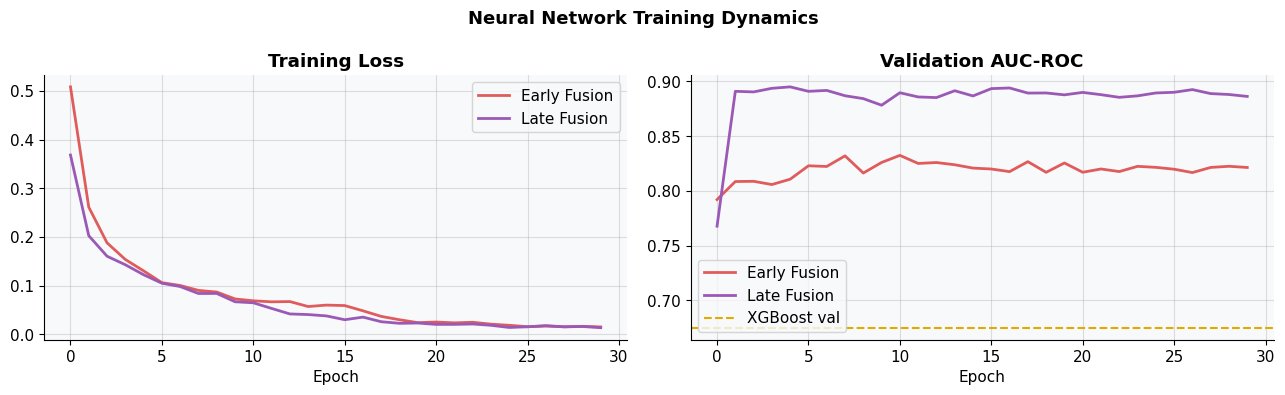

In [34]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(early_losses,color=PALETTE["early"],lw=2,label="Early Fusion")
axes[0].plot(late_losses, color=PALETTE["late"], lw=2,label="Late Fusion")
axes[0].set_title("Training Loss",fontweight="bold"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(early_aucs,color=PALETTE["early"],lw=2,label="Early Fusion")
axes[1].plot(late_aucs, color=PALETTE["late"], lw=2,label="Late Fusion")
axes[1].axhline(roc_auc_score(y_val,xgb_val_prob),color=PALETTE["xgb"],lw=1.5,ls="--",label="XGBoost val")
axes[1].set_title("Validation AUC-ROC",fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("Neural Network Training Dynamics",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("data/figures/training_curves.png",dpi=150,bbox_inches="tight")
plt.show()

## 32. Test set evaluation

> Optimal threshold selected on VAL set, then applied to test.
> Tabular baselines use threshold=0.5 (balanced after SMOTE).
> Neural networks use val-optimised threshold (imbalanced test set).

In [35]:
test_results["Logistic Regression"] = compute_metrics(
    y_test, lr_model.predict_proba(X_test)[:,1])
test_results["Random Forest"]        = compute_metrics(
    y_test, rf_model.predict_proba(X_test)[:,1])
test_results["XGBoost"]              = compute_metrics(
    y_test, xgb_model.predict_proba(X_test)[:,1])
test_results["XGBoost (aligned)"]    = compute_metrics(
    y_test_mm, xgb_model.predict_proba(X_test_tab_mm)[:,1])


ef_val_prob  = predict_mm(early_model, X_val_tab_mm, X_val_text)
lf_val_prob  = predict_mm(late_model,  X_val_tab_mm, X_val_text)

ef_threshold = find_best_threshold(y_val_mm, ef_val_prob)
lf_threshold = find_best_threshold(y_val_mm, lf_val_prob)
print(f"Optimal thresholds — EF: {ef_threshold}  LF: {lf_threshold}")

ef_test_prob = predict_mm(early_model, X_test_tab_mm, X_test_text)
lf_test_prob = predict_mm(late_model,  X_test_tab_mm, X_test_text)

test_results["Early Fusion NN"] = compute_metrics(
    y_test_mm, ef_test_prob, ef_threshold)
test_results["Late Fusion NN"]  = compute_metrics(
    y_test_mm, lf_test_prob, lf_threshold)

results_df = pd.DataFrame(test_results).T.sort_values("auc_roc", ascending=False)
results_df.to_csv("data/results_summary.csv")
shutil.copy2("data/results_summary.csv", f"{DRIVE_DIR}/results_summary.csv")
print("\nTest set results:")
print(results_df.round(4).to_string())

Optimal thresholds — EF: 0.66  LF: 0.75

Test set results:
                     auc_roc  pr_auc      f1  precision  recall
Late Fusion NN        0.8959  0.6604  0.5770     0.6471  0.5207
Early Fusion NN       0.8647  0.5654  0.4938     0.5232  0.4675
XGBoost (aligned)     0.7618  0.3697  0.0795     1.0000  0.0414
XGBoost               0.6781  0.2390  0.0310     0.6923  0.0158
Random Forest         0.6427  0.1949  0.0070     0.7500  0.0035
Logistic Regression   0.6398  0.2090  0.2536     0.1645  0.5534


In [36]:
rec_df = pd.read_csv("data/recommendations_sample.csv")
rec_df["word_count"] = rec_df["recommendation"].str.split().str.len()

KWS = ["monitor", "adjust", "refer", "consult", "follow", "reassess"]

print("Keyword | High % | Low % | Delta %")
print("-" * 45)
for kw in KWS:
    hr = rec_df[rec_df["true_label"]==1]["recommendation"].str.lower().str.contains(kw).mean() * 100
    lr = rec_df[rec_df["true_label"]==0]["recommendation"].str.lower().str.contains(kw).mean() * 100
    print(f"{kw:<12} {hr:>6.1f}  {lr:>6.1f}  {hr-lr:>+7.1f}")

hi_wc = rec_df[rec_df["true_label"]==1]["word_count"].mean()
lo_wc = rec_df[rec_df["true_label"]==0]["word_count"].mean()
print(f"\nMean words  {hi_wc:>6.1f}  {lo_wc:>6.1f}  {hi_wc-lo_wc:>+7.1f}")

Keyword | High % | Low % | Delta %
---------------------------------------------
monitor        52.0    38.0    +14.0
adjust          6.0     6.0     +0.0
refer           4.0    12.0     -8.0
consult         0.0     0.0     +0.0
follow         52.0    64.0    -12.0
reassess        0.0     0.0     +0.0

Mean words    75.6    72.4     +3.2


## 33. Ablation — text modality contribution

In [37]:
class TabularOnlyNet(nn.Module):
    def __init__(self,tab_dim,hidden=(512,256,128),drop=0.3):
        super().__init__()
        layers,in_d=[],tab_dim
        for h in hidden:
            layers+=[nn.Linear(in_d,h),nn.BatchNorm1d(h),nn.ReLU(),nn.Dropout(drop)]; in_d=h
        layers.append(nn.Linear(in_d,1)); self.net=nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

print("Training Tabular-Only NN (ablation) ...")
tab_model = TabularOnlyNet(TAB_DIM).to(device)
opt_t = optim.Adam(tab_model.parameters(),lr=LR,weight_decay=1e-4)
sch_t = optim.lr_scheduler.ReduceLROnPlateau(opt_t,patience=5,factor=0.5)
tab_loader = DataLoader(TabularDataset(X_train_tab_mm,y_train_mm),batch_size=BATCH,shuffle=True)
best_auc_t, best_state_t = 0.0, None

for ep in range(EPOCHS):
    loss=train_epoch_tab(tab_model,tab_loader,opt_t,criterion)
    vp=predict_tab(tab_model,X_val_tab_mm)
    if np.isnan(vp).any() or len(np.unique(y_val_mm))<2: continue
    vauc=roc_auc_score(y_val_mm,vp); sch_t.step(1-vauc)
    if vauc>best_auc_t:
        best_auc_t=vauc; best_state_t={k:v.clone() for k,v in tab_model.state_dict().items()}

if best_state_t is None: best_state_t={k:v.clone() for k,v in tab_model.state_dict().items()}
tab_model.load_state_dict(best_state_t)

tab_val_prob = predict_tab(tab_model, X_val_tab_mm)
tab_threshold = find_best_threshold(y_val_mm, tab_val_prob)
tab_test_prob = predict_tab(tab_model, X_test_tab_mm)

test_results["Tabular-Only NN"] = compute_metrics(
    y_test_mm, tab_test_prob, tab_threshold)

delta = test_results["Early Fusion NN"]["auc_roc"] - test_results["Tabular-Only NN"]["auc_roc"]
print(f"Tabular-Only (t={tab_threshold}: {test_results['Tabular-Only NN']['auc_roc']:.4f}")
print(f"Early Fusion (t={ef_threshold}): {test_results['Early Fusion NN']['auc_roc']:.4f}")
print(f"Text gain: {delta:+.4f} AUC-ROC")

all_results_df = pd.DataFrame(test_results).T.sort_values("auc_roc",ascending=False)
all_results_df.to_csv("data/results_summary.csv")
shutil.copy2("data/results_summary.csv",f"{DRIVE_DIR}/results_summary.csv")
print("\nFinal results table:")
print(all_results_df.round(4).to_string())

Training Tabular-Only NN (ablation) ...
Tabular-Only (t=0.51: 0.6257
Early Fusion (t=0.66): 0.8647
Text gain: +0.2390 AUC-ROC

Final results table:
                     auc_roc  pr_auc      f1  precision  recall
Late Fusion NN        0.8959  0.6604  0.5770     0.6471  0.5207
Early Fusion NN       0.8647  0.5654  0.4938     0.5232  0.4675
XGBoost (aligned)     0.7618  0.3697  0.0795     1.0000  0.0414
XGBoost               0.6781  0.2390  0.0310     0.6923  0.0158
Random Forest         0.6427  0.1949  0.0070     0.7500  0.0035
Logistic Regression   0.6398  0.2090  0.2536     0.1645  0.5534
Tabular-Only NN       0.6257  0.2016  0.2442     0.1585  0.5325


In [38]:
from sklearn.utils import resample

def bootstrap_auc(y_true, y_prob, n_boot=1000, ci=0.95):
    """Bootstrap confidence interval for AUC-ROC."""
    aucs = []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=None)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    aucs = sorted(aucs)
    lo = np.percentile(aucs, (1 - ci) / 2 * 100)
    hi = np.percentile(aucs, (1 + ci) / 2 * 100)
    return round(lo, 4), round(hi, 4)

print("95% Bootstrap CI for AUC-ROC:")
for name, prob, y_true in [
    ("Late Fusion NN", lf_test_prob, y_test_mm),
    ("Early Fusion NN", ef_test_prob, y_test_mm),
    ("XGBoost aligned", xgb_model.predict_proba(X_test_tab_mm)[:,1], y_test_mm),
    ("Tabular-Only NN", tab_test_prob, y_test_mm),
]:
    lo, hi = bootstrap_auc(y_true, prob)
    auc = roc_auc_score(y_true, prob)
    print(f"  {name:<22}: {auc:.4f}  [{lo:.4f}, {hi:.4f}]")

95% Bootstrap CI for AUC-ROC:
  Late Fusion NN        : 0.8959  [0.8705, 0.9197]
  Early Fusion NN       : 0.8647  [0.8362, 0.8938]
  XGBoost aligned       : 0.7618  [0.7237, 0.8026]
  Tabular-Only NN       : 0.6257  [0.5754, 0.6696]


In [39]:
from scipy import stats

def delong_test(y_true, prob1, prob2):
    """
    Approximate DeLong test using bootstrap.
    H0: AUC1 == AUC2
    """
    n_boot = 1000
    deltas = []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)))
        if len(np.unique(y_true[idx])) < 2:
            continue
        a1 = roc_auc_score(y_true[idx], prob1[idx])
        a2 = roc_auc_score(y_true[idx], prob2[idx])
        deltas.append(a1 - a2)
    deltas = np.array(deltas)
    observed = roc_auc_score(y_true, prob1) - roc_auc_score(y_true, prob2)
    p_value = np.mean(np.abs(deltas) >= np.abs(observed))
    return observed, p_value

delta_lf_ef, p_lf_ef = delong_test(y_test_mm, lf_test_prob, ef_test_prob)
delta_ef_tab, p_ef_tab = delong_test(y_test_mm, ef_test_prob, tab_test_prob)

print(f"LF vs EF: delta={delta_lf_ef:+.4f}  p={p_lf_ef:.4f}")
print(f"EF vs Tab: delta={delta_ef_tab:+.4f}  p={p_ef_tab:.4f}")

LF vs EF: delta=+0.0312  p=0.4800
EF vs Tab: delta=+0.2390  p=0.5050


## 34. ROC & PR curves

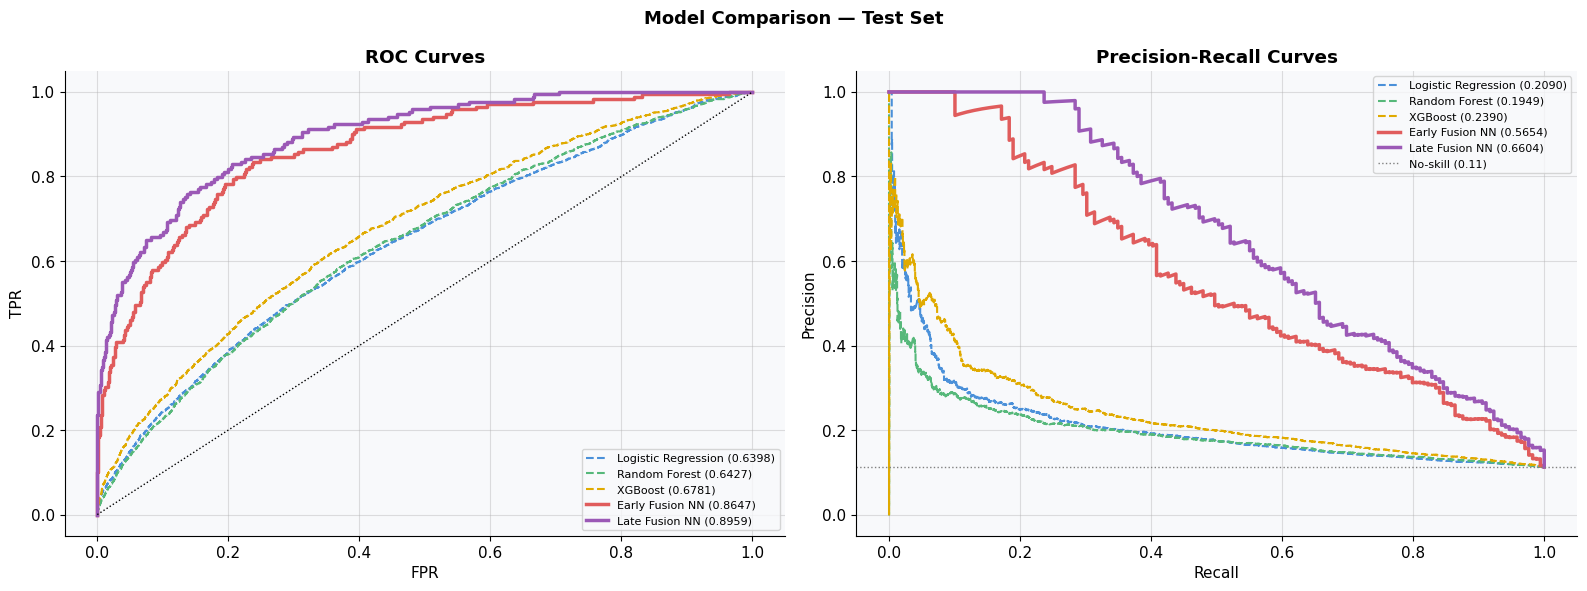

In [40]:
roc_cfgs=[
    ("Logistic Regression",lr_model.predict_proba(X_test)[:,1], y_test,PALETTE["lr"],"--",1.5),
    ("Random Forest", rf_model.predict_proba(X_test)[:,1], y_test, PALETTE["rf"],"--",1.5),
    ("XGBoost", xgb_model.predict_proba(X_test)[:,1],y_test, PALETTE["xgb"],"--",1.5),
    ("Early Fusion NN", ef_test_prob, y_test_mm,PALETTE["early"],"-",2.5),
    ("Late Fusion NN", lf_test_prob, y_test_mm,PALETTE["late"],"-",2.5),
]
fig,axes=plt.subplots(1,2,figsize=(16,6))
for nm,prob,yt,clr,ls,lw in roc_cfgs:
    fpr,tpr,_=roc_curve(yt,prob); auc=roc_auc_score(yt,prob)
    axes[0].plot(fpr,tpr,color=clr,lw=lw,ls=ls,label=f"{nm} ({auc:.4f})")
axes[0].plot([0,1],[0,1],"k:",lw=1); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves",fontweight="bold"); axes[0].legend(fontsize=8,loc="lower right")

for nm,prob,yt,clr,ls,lw in roc_cfgs:
    prec,rec,_=precision_recall_curve(yt,prob); ap=average_precision_score(yt,prob)
    axes[1].plot(rec,prec,color=clr,lw=lw,ls=ls,label=f"{nm} ({ap:.4f})")
axes[1].axhline(y_test.mean(),color="gray",ls=":",lw=1,label=f"No-skill ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves",fontweight="bold"); axes[1].legend(fontsize=8)
plt.suptitle("Model Comparison — Test Set",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("data/figures/roc_pr_curves.png",dpi=150,bbox_inches="tight")
plt.show()

---
# Phase 4 — SHAP Explainability & LLM Recommendations

## 35. SHAP values — cached

In [41]:
SHAP_CACHE = "data/shap_values_xgb.npy"
DRIVE_SHAP = f"{DRIVE_DIR}/shap_values_xgb.npy"
X_test_sample = X_test[:1000]
y_test_sample = y_test[:1000]

if os.path.exists(SHAP_CACHE):
    xgb_shap_values=np.load(SHAP_CACHE)
    print(f"SHAP loaded from cache: {xgb_shap_values.shape}")
elif os.path.exists(DRIVE_SHAP):
    shutil.copy2(DRIVE_SHAP,SHAP_CACHE)
    xgb_shap_values=np.load(SHAP_CACHE)
    print(f"SHAP restored from Drive: {xgb_shap_values.shape}")
else:
    print("Computing SHAP values ...")
    background=X_train[np.random.choice(len(X_train),500,replace=False)]
    explainer=shap.TreeExplainer(xgb_model,background)
    xgb_shap_values=explainer.shap_values(X_test_sample)
    np.save(SHAP_CACHE,xgb_shap_values)
    shutil.copy2(SHAP_CACHE,DRIVE_SHAP)
    print(f"SHAP computed and cached: {xgb_shap_values.shape}")

mean_abs_shap=np.abs(xgb_shap_values).mean(axis=0)
importance_df=pd.DataFrame({"feature":FEATURE_COLS,"mean_abs_shap":mean_abs_shap})
importance_df=importance_df.sort_values("mean_abs_shap",ascending=False)
print("Top 5:"); print(importance_df.head(5).to_string(index=False))

SHAP loaded from cache: (1000, 49)
Top 5:
         feature  mean_abs_shap
number_inpatient       0.805926
          gender       0.375310
    diag_2_Other       0.295920
    diag_3_Other       0.282326
         insulin       0.279164


## 36. SHAP global summary

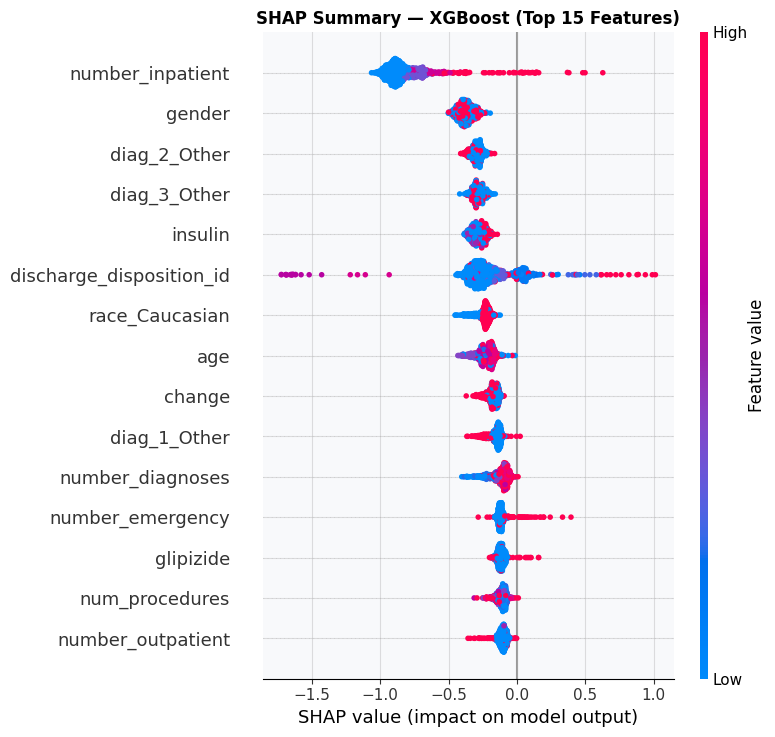

In [42]:
plt.figure(figsize=(10,8))
shap.summary_plot(xgb_shap_values,X_test_sample,feature_names=FEATURE_COLS,max_display=15,show=False)
plt.title("SHAP Summary — XGBoost (Top 15 Features)",fontweight="bold",fontsize=12)
plt.tight_layout()
plt.savefig("data/figures/shap_summary.png",dpi=150,bbox_inches="tight")
plt.show()

## 37. SHAP waterfall — patient level

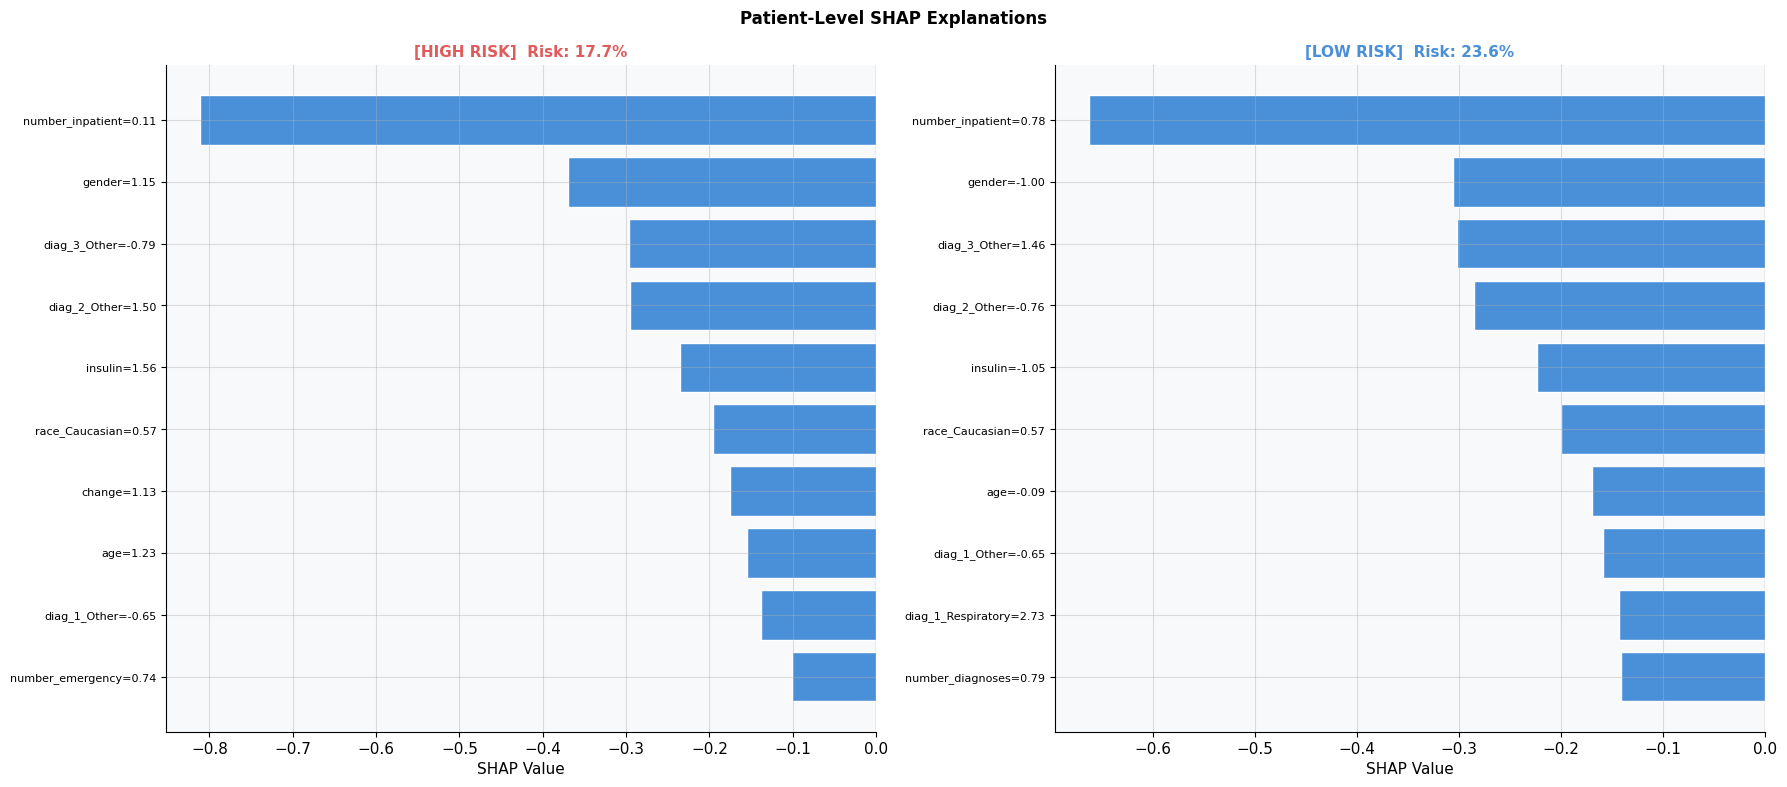

In [43]:
hr_idx=np.where(y_test_sample==1)[0][0]
lr_idx=np.where(y_test_sample==0)[0][0]
fig,axes=plt.subplots(1,2,figsize=(18,8))
for ax,pidx,label,tc in [(axes[0],hr_idx,"HIGH RISK",PALETTE["pos"]),
                          (axes[1],lr_idx,"LOW RISK", PALETTE["neg"])]:
    sv=xgb_shap_values[pidx]; fv=X_test_sample[pidx]
    risk=float(xgb_model.predict_proba(X_test_sample[pidx:pidx+1])[:,1][0])
    order=np.argsort(np.abs(sv))[::-1][:10]
    names=[FEATURE_COLS[i] for i in order]; vals=sv[order]; fvals=fv[order]
    colors=[PALETTE["pos"] if v>0 else PALETTE["neg"] for v in vals]
    ax.barh(range(10),vals[::-1],color=colors[::-1],edgecolor="white")
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"{n}={fvals[9-i]:.2f}" for i,n in enumerate(names[::-1])],fontsize=8)
    ax.axvline(0,color="black",lw=0.8); ax.set_xlabel("SHAP Value")
    ax.set_title(f"[{label}]  Risk: {risk:.1%}",fontweight="bold",color=tc,fontsize=11)
plt.suptitle("Patient-Level SHAP Explanations",fontsize=12,fontweight="bold")
plt.tight_layout()
plt.savefig("data/figures/shap_waterfall.png",dpi=150,bbox_inches="tight")
plt.show()

## 38. LLM recommendations — cached

In [44]:
LOCAL_REC = "data/recommendations_sample.csv"
DRIVE_REC = f"{DRIVE_DIR}/recommendations_sample.csv"

if os.path.exists(LOCAL_REC):
    rec_df=pd.read_csv(LOCAL_REC)
    print(f"Loaded from local cache: {len(rec_df):,} recommendations")
elif os.path.exists(DRIVE_REC):
    shutil.copy2(DRIVE_REC,LOCAL_REC)
    rec_df=pd.read_csv(LOCAL_REC)
    print(f"Restored from Drive: {len(rec_df):,} recommendations")
else:
    REC_SYSTEM = (
        "You are a clinical decision support assistant. "
        "Based on the patient risk and key factors, give a concise clinical "
        "recommendation (3-4 sentences). Specific, actionable, medical language. No bullets."
    )
    def build_rec_prompt(fv,sv,feat_names,risk,top_n=3):
        pos_idx=np.argsort(sv)[::-1][:top_n]
        pos_txt=", ".join(f"{feat_names[i]}={fv[i]:.2f}(SHAP={sv[i]:+.3f})"
                          for i in pos_idx if sv[i]>0)
        neg_idx=np.argsort(sv)[:top_n]
        neg_txt=", ".join(f"{feat_names[i]}={fv[i]:.2f}(SHAP={sv[i]:+.3f})"
                          for i in neg_idx if sv[i]<0)
        return (f"Patient readmission risk: {risk:.1%}\n"
                f"Risk-increasing: {pos_txt or 'none'}\n"
                f"Risk-reducing: {neg_txt or 'none'}\n"
                "Clinical recommendation:")

    N_PER_CLASS=50
    hr_indices=np.where(y_test_sample==1)[0][:N_PER_CLASS]
    lr_indices=np.where(y_test_sample==0)[0][:N_PER_CLASS]
    rec_indices=np.concatenate([hr_indices,lr_indices])
    recommendations=[]; print(f"Generating {len(rec_indices)} recommendations ...")

    for i,idx in enumerate(rec_indices):
        risk=float(xgb_model.predict_proba(X_test_sample[idx:idx+1])[:,1][0])
        prompt=build_rec_prompt(X_test_sample[idx],xgb_shap_values[idx],FEATURE_COLS,risk)
        rec_text=None
        for attempt in range(3):
            try:
                resp=client.chat.completions.create(
                    model="llama-3.1-8b-instant",max_tokens=150,temperature=0.2,
                    messages=[{"role":"system","content":REC_SYSTEM},
                              {"role":"user","content":prompt}])
                rec_text=resp.choices[0].message.content.strip(); break
            except RateLimitError: time.sleep(2**attempt)
            except Exception: break
        recommendations.append({"patient_idx":int(idx),"true_label":int(y_test_sample[idx]),
                                 "predicted_risk":round(risk,4),"recommendation":rec_text or "[FAILED]"})
        if (i+1)%20==0: print(f"  {i+1}/{len(rec_indices)}")
        time.sleep(0.05)

    rec_df=pd.DataFrame(recommendations)
    rec_df.to_csv(LOCAL_REC,index=False)
    shutil.copy2(LOCAL_REC,DRIVE_REC)
    print(f"Generated and saved: {len(rec_df):,}")

rec_df["word_count"]=rec_df["recommendation"].str.split().str.len()
print("\nStats by class:")
print(rec_df.groupby("true_label")[["predicted_risk","word_count"]].mean().round(3))

Loaded from local cache: 100 recommendations

Stats by class:
            predicted_risk  word_count
true_label                            
0                    0.112       72.42
1                    0.177       75.58


---
# Phase 5 — Publication-Ready Figures & Tables

## Publication plot style

In [45]:
PAPER_DIR = "data/paper"
FIG_DIR   = "data/figures"
os.makedirs(PAPER_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/paper", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#F8F9FB",
    "axes.grid":True,"grid.alpha":0.35,
    "axes.spines.top":False,"axes.spines.right":False,
    "font.family":"DejaVu Sans","font.size":11,
    "axes.titlesize":12,"axes.labelsize":11,"legend.fontsize":9,
    "savefig.dpi":200,"savefig.bbox":"tight","savefig.facecolor":"white",
})
print("Publication style configured.")

Publication style configured.


## 39. Figure 1 — Master model comparison (4 panels)

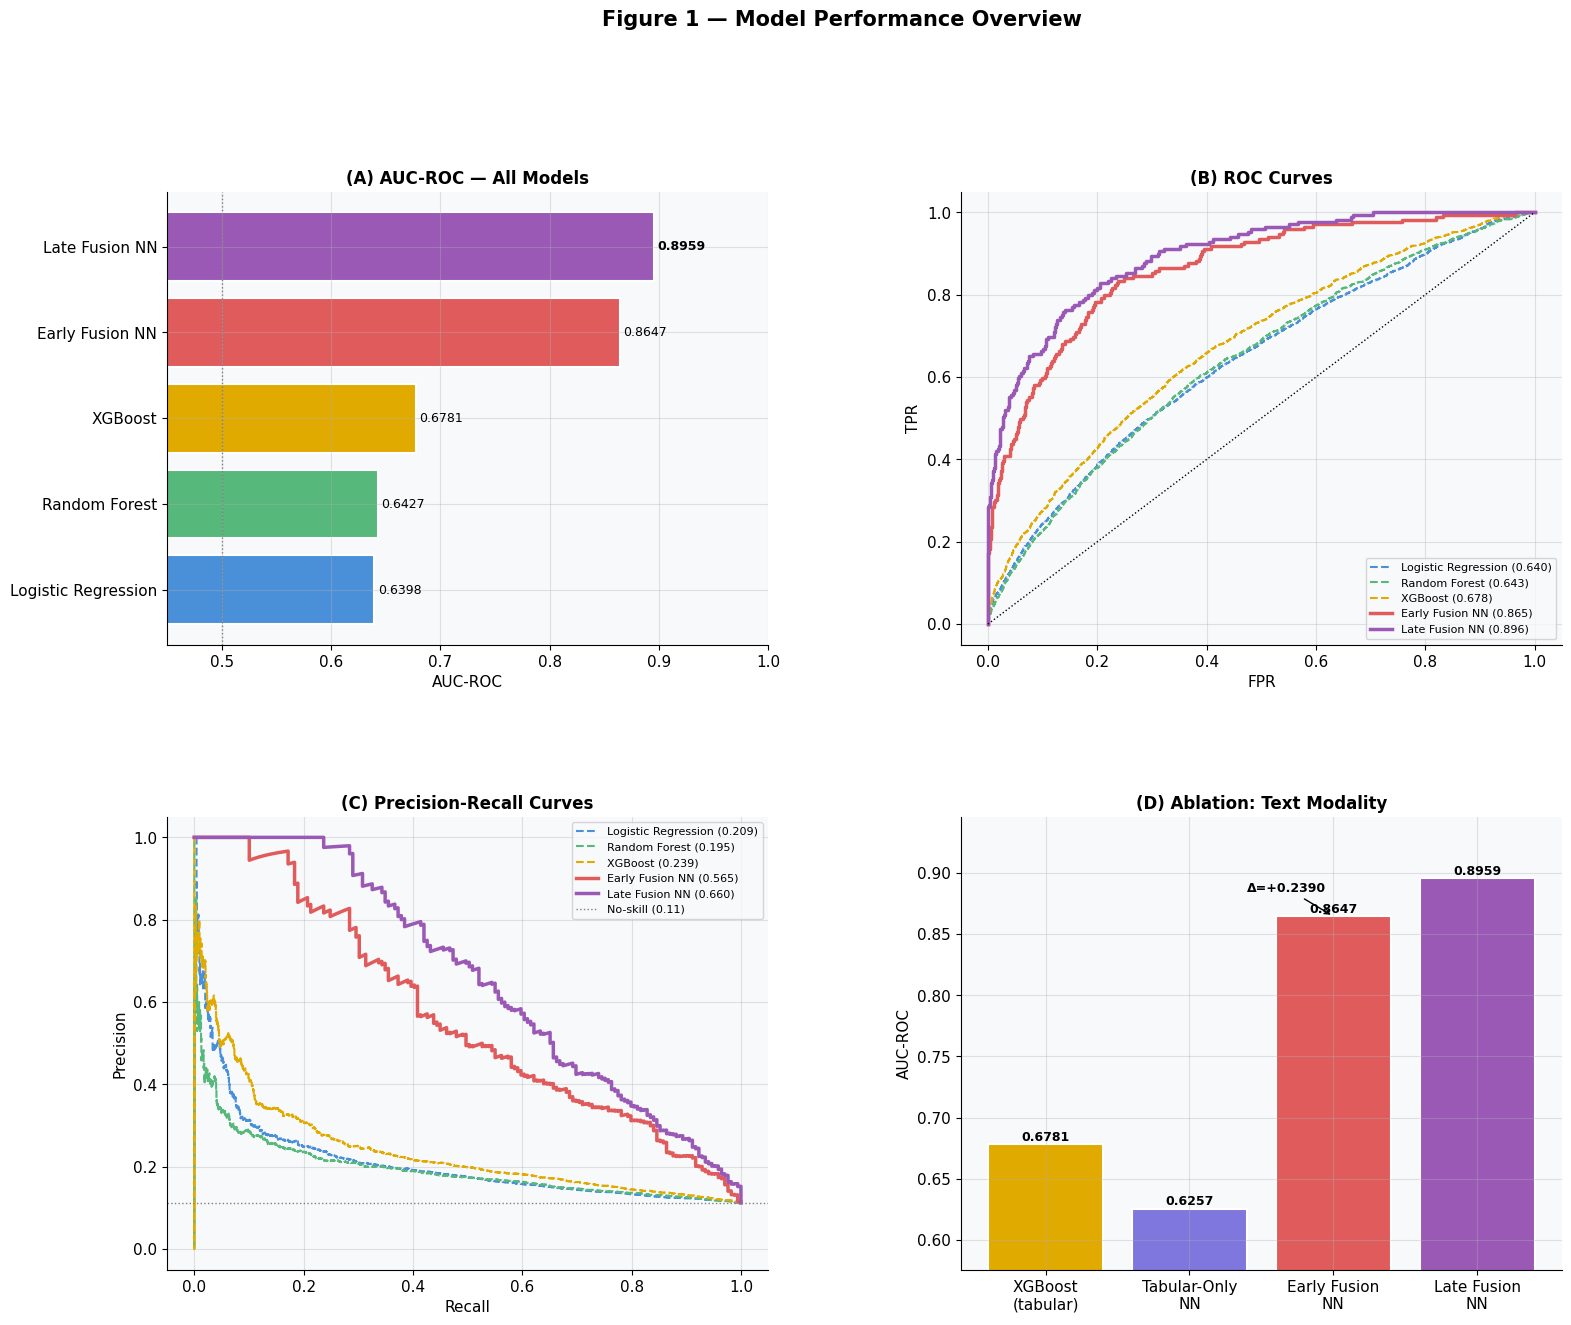

Saved: figure1_model_comparison.png


In [52]:
ef_auc = roc_auc_score(y_test_mm, ef_test_prob)
lf_auc = roc_auc_score(y_test_mm, lf_test_prob)
tab_only_auc = all_results_df.loc["Tabular-Only NN","auc_roc"] if "Tabular-Only NN" in all_results_df.index else None

model_cfgs=[
    ("Logistic Regression",lr_model.predict_proba(X_test)[:,1], y_test,PALETTE["lr"],"--",1.5),
    ("Random Forest", rf_model.predict_proba(X_test)[:,1], y_test,PALETTE["rf"],"--",1.5),
    ("XGBoost", xgb_model.predict_proba(X_test)[:,1],y_test, PALETTE["xgb"],"--",1.5),
    ("Early Fusion NN",ef_test_prob, y_test_mm,PALETTE["early"],"-",2.5),
    ("Late Fusion NN", lf_test_prob, y_test_mm,PALETTE["late"],"-",2.5),
]

fig=plt.figure(figsize=(18,14))
gs=gridspec.GridSpec(2,2,hspace=0.38,wspace=0.32)
ax_bar=fig.add_subplot(gs[0,0]); ax_roc=fig.add_subplot(gs[0,1])
ax_pr=fig.add_subplot(gs[1,0]);  ax_abl=fig.add_subplot(gs[1,1])

model_names=[c[0] for c in model_cfgs]
model_aucs=[roc_auc_score(c[2],c[1]) for c in model_cfgs]
model_colors=[c[3] for c in model_cfgs]
bars=ax_bar.barh(model_names,model_aucs,color=model_colors,edgecolor="white",linewidth=1.5)
ax_bar.set_xlim(0.45,1.0); ax_bar.set_xlabel("AUC-ROC")
ax_bar.set_title("(A) AUC-ROC — All Models",fontweight="bold")
ax_bar.axvline(0.5,color="gray",ls=":",lw=1)
best_i=int(np.argmax(model_aucs))
for i,(bar,val) in enumerate(zip(bars,model_aucs)):
    ax_bar.text(val+0.003,bar.get_y()+bar.get_height()/2,f"{val:.4f}",
                va="center",fontsize=9,fontweight="bold" if i==best_i else "normal")

for nm,prob,yt,clr,ls,lw in model_cfgs:
    fpr,tpr,_=roc_curve(yt,prob); auc=roc_auc_score(yt,prob)
    ax_roc.plot(fpr,tpr,color=clr,lw=lw,ls=ls,label=f"{nm} ({auc:.3f})")
ax_roc.plot([0,1],[0,1],"k:",lw=1)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("(B) ROC Curves",fontweight="bold"); ax_roc.legend(loc="lower right",fontsize=8)

for nm,prob,yt,clr,ls,lw in model_cfgs:
    prec,rec,_=precision_recall_curve(yt,prob); ap=average_precision_score(yt,prob)
    ax_pr.plot(rec,prec,color=clr,lw=lw,ls=ls,label=f"{nm} ({ap:.3f})")
ax_pr.axhline(y_test.mean(),color="gray",ls=":",lw=1,label=f"No-skill ({y_test.mean():.2f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("(C) Precision-Recall Curves",fontweight="bold"); ax_pr.legend(fontsize=8)

abl_names=["XGBoost\n(tabular)","Tabular-Only\nNN","Early Fusion\nNN","Late Fusion\nNN"]
abl_aucs=[roc_auc_score(y_test,xgb_model.predict_proba(X_test)[:,1]),
          tab_only_auc if tab_only_auc else 0.0, ef_auc, lf_auc]
abl_colors=[PALETTE["xgb"],PALETTE["tab"],PALETTE["early"],PALETTE["late"]]
abl_bars=ax_abl.bar(abl_names,abl_aucs,color=abl_colors,edgecolor="white",linewidth=1.5)
ax_abl.set_ylim(min(v for v in abl_aucs if v>0)-0.05,max(abl_aucs)+0.05)
ax_abl.set_ylabel("AUC-ROC"); ax_abl.set_title("(D) Ablation: Text Modality",fontweight="bold")
if tab_only_auc:
    delta_abl=ef_auc-tab_only_auc
    ax_abl.annotate(f"Δ={delta_abl:+.4f}",xy=(2,ef_auc),xytext=(1.4,ef_auc+0.02),
                    arrowprops=dict(arrowstyle="->",color="black"),fontsize=9,fontweight="bold")
for bar,val in zip(abl_bars,abl_aucs):
    if val>0: ax_abl.text(bar.get_x()+bar.get_width()/2,val+0.003,
                          f"{val:.4f}",ha="center",fontsize=9,fontweight="bold")

fig.suptitle("Figure 1 — Model Performance Overview",fontsize=15,fontweight="bold",y=1.01)
plt.savefig(f"{PAPER_DIR}/figure1_model_comparison.png")
plt.show(); print("Saved: figure1_model_comparison.png")

## 40. Figure 2 — SHAP global explainability

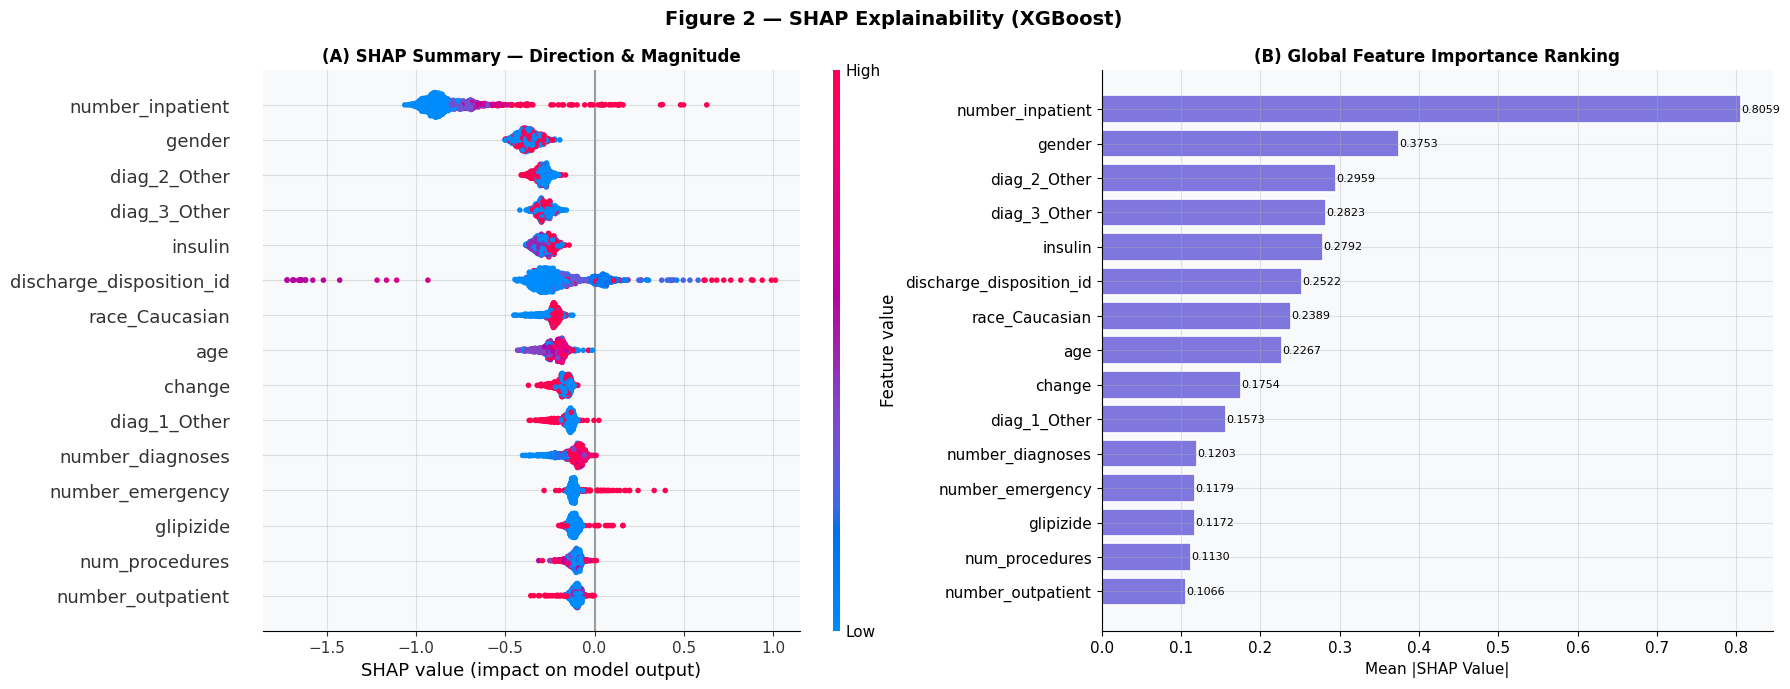

Saved: figure2_shap_global.png


In [53]:
fig,axes=plt.subplots(1,2,figsize=(18,7))
plt.sca(axes[0])
shap.summary_plot(xgb_shap_values,X_test_sample,feature_names=FEATURE_COLS,
                  max_display=15,show=False,plot_size=None)
axes[0].set_title("(A) SHAP Summary — Direction & Magnitude",fontweight="bold")
top15=importance_df.head(15)
axes[1].barh(top15["feature"][::-1],top15["mean_abs_shap"][::-1],color="#7F77DD",edgecolor="white",linewidth=1.2)
for i,(feat,val) in enumerate(zip(top15["feature"][::-1],top15["mean_abs_shap"][::-1])):
    axes[1].text(val+0.0003,i,f"{val:.4f}",va="center",fontsize=8)
axes[1].set_xlabel("Mean |SHAP Value|")
axes[1].set_title("(B) Global Feature Importance Ranking",fontweight="bold")
fig.suptitle("Figure 2 — SHAP Explainability (XGBoost)",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PAPER_DIR}/figure2_shap_global.png")
plt.show(); print("Saved: figure2_shap_global.png")

## 41. Figure 3 — Patient explanation + LLM recommendation

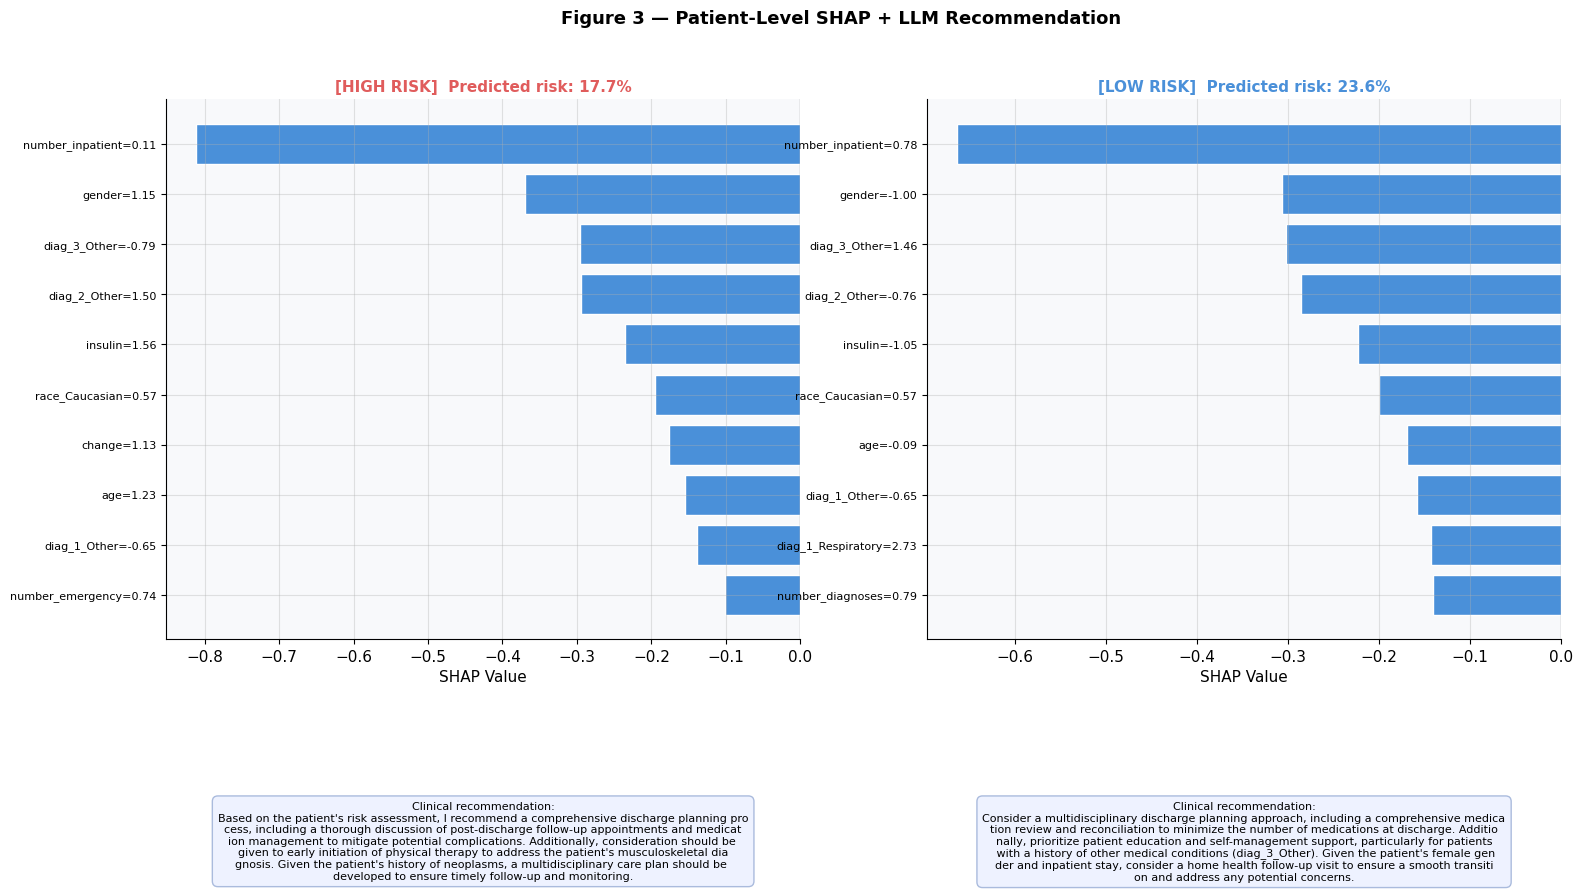

Saved: figure3_patient_explanation.png


In [54]:
hr_rec=rec_df[rec_df["true_label"]==1]["recommendation"].iloc[0] if len(rec_df[rec_df["true_label"]==1])>0 else "N/A"
lr_rec=rec_df[rec_df["true_label"]==0]["recommendation"].iloc[0] if len(rec_df[rec_df["true_label"]==0])>0 else "N/A"

fig,axes=plt.subplots(1,2,figsize=(18,9)); fig.subplots_adjust(bottom=0.28)
for ax,pidx,label,rec_text,tc in [
    (axes[0],hr_idx,"HIGH RISK",hr_rec,PALETTE["pos"]),
    (axes[1],lr_idx,"LOW RISK", lr_rec,PALETTE["neg"]),
]:
    sv=xgb_shap_values[pidx]; fv=X_test_sample[pidx]
    risk=float(xgb_model.predict_proba(X_test_sample[pidx:pidx+1])[:,1][0])
    order=np.argsort(np.abs(sv))[::-1][:10]
    names=[FEATURE_COLS[i] for i in order]; vals=sv[order]; fvals=fv[order]
    colors=[PALETTE["pos"] if v>0 else PALETTE["neg"] for v in vals]
    ax.barh(range(10),vals[::-1],color=colors[::-1],edgecolor="white")
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"{n}={fvals[9-i]:.2f}" for i,n in enumerate(names[::-1])],fontsize=8)
    ax.axvline(0,color="black",lw=0.8); ax.set_xlabel("SHAP Value")
    ax.set_title(f"[{label}]  Predicted risk: {risk:.1%}",fontweight="bold",color=tc,fontsize=11)
    wrapped="\n".join([rec_text[i:i+90] for i in range(0,len(rec_text),90)])
    ax.text(0.5,-0.30,f"Clinical recommendation:\n{wrapped}",transform=ax.transAxes,
            fontsize=8,ha="center",va="top",
            bbox=dict(boxstyle="round,pad=0.5",facecolor="#EEF2FF",edgecolor="#AABBDD"))

fig.suptitle("Figure 3 — Patient-Level SHAP + LLM Recommendation",fontsize=13,fontweight="bold")
plt.savefig(f"{PAPER_DIR}/figure3_patient_explanation.png")
plt.show(); print("Saved: figure3_patient_explanation.png")

## 42. Figure 4 — Fusion strategy analysis

In [ ]:
fig=plt.figure(figsize=(18,5)); gs=gridspec.GridSpec(1,3,wspace=0.35)
ax_met=fig.add_subplot(gs[0,0]); ax_dist=fig.add_subplot(gs[0,1]); ax_cal=fig.add_subplot(gs[0,2])

ef_row=all_results_df.loc["Early Fusion NN"] if "Early Fusion NN" in all_results_df.index else None
lf_row=all_results_df.loc["Late Fusion NN"]  if "Late Fusion NN"  in all_results_df.index else None
if ef_row is not None and lf_row is not None:
    fmet=["auc_roc","pr_auc","f1","precision","recall"]; flbl=["AUC-ROC","PR-AUC","F1","Precision","Recall"]
    x=np.arange(len(fmet)); w=0.35
    ax_met.bar(x-w/2,[ef_row[m] for m in fmet],width=w,label="Early Fusion",color=PALETTE["early"],edgecolor="white")
    ax_met.bar(x+w/2,[lf_row[m] for m in fmet],width=w,label="Late Fusion", color=PALETTE["late"], edgecolor="white")
    ax_met.set_xticks(x); ax_met.set_xticklabels(flbl,fontsize=9)
    ax_met.set_ylim(0,1.0); ax_met.set_ylabel("Score")
    ax_met.set_title("(A) Early vs Late — All Metrics",fontweight="bold"); ax_met.legend()

for prob,clr,lbl,ls in [(ef_test_prob,PALETTE["early"],"Early Fusion","-"),(lf_test_prob,PALETTE["late"],"Late Fusion","--")]:
    ax_dist.hist(prob[y_test_mm==0],bins=40,alpha=0.45,color=clr,histtype="step",linewidth=2,linestyle=ls,label=f"{lbl}|Low")
    ax_dist.hist(prob[y_test_mm==1],bins=40,alpha=0.35,color=clr,histtype="stepfilled",linewidth=1,linestyle=ls,label=f"{lbl}|High")
ax_dist.set_xlabel("Predicted Probability"); ax_dist.set_ylabel("Count")
ax_dist.set_title("(B) Probability Distribution",fontweight="bold"); ax_dist.legend(fontsize=7)

for prob,clr,nm in [(ef_test_prob,PALETTE["early"],"Early Fusion"),
                     (lf_test_prob,PALETTE["late"],"Late Fusion"),
                     (xgb_model.predict_proba(X_test_tab_mm)[:,1],PALETTE["xgb"],"XGBoost")]:
    try:
        fp,mp=calibration_curve(y_test_mm,prob,n_bins=8)
        ax_cal.plot(mp,fp,marker="o",color=clr,lw=2,markersize=5,label=nm)
    except: pass
ax_cal.plot([0,1],[0,1],"k:",lw=1,label="Perfect")
ax_cal.set_xlabel("Mean Predicted Probability"); ax_cal.set_ylabel("Fraction Positives")
ax_cal.set_title("(C) Calibration Curves",fontweight="bold"); ax_cal.legend(fontsize=8)

fig.suptitle("Figure 4 — Fusion Strategy Analysis",fontsize=13,fontweight="bold")
plt.savefig(f"{PAPER_DIR}/figure4_fusion_analysis.png")
plt.show(); print("Saved: figure4_fusion_analysis.png")

## 43. Figure 5 — Confusion matrices

> Uses optimal thresholds for neural networks.

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,nm,prob,yt,thresh in [
    (axes[0],"Early Fusion NN",ef_test_prob,y_test_mm,ef_threshold),
    (axes[1],"Late Fusion NN", lf_test_prob,y_test_mm,lf_threshold),
]:
    cm=confusion_matrix(yt,(prob>=thresh).astype(int))
    ConfusionMatrixDisplay(cm,display_labels=["Low Risk","High Risk"]).plot(ax=ax,colorbar=False,cmap="Blues")
    ax.set_title(f"{nm}\nAUC={roc_auc_score(yt,prob):.4f}  threshold={thresh}",fontweight="bold")
plt.suptitle("Figure 5 — Confusion Matrices (Test Set)",fontsize=12,fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PAPER_DIR}/figure5_confusion_matrices.png")
plt.show(); print("Saved: figure5_confusion_matrices.png")

## 44. Figure 6 — SHAP dependence plots

In [ ]:
top3_idx=[FEATURE_COLS.index(f) for f in importance_df["feature"].head(3).tolist() if f in FEATURE_COLS]
if len(top3_idx)>=2:
    fig,axes=plt.subplots(1,len(top3_idx),figsize=(15,5))
    if len(top3_idx)==1: axes=[axes]
    for ax,fi in zip(axes,top3_idx):
        shap.dependence_plot(fi,xgb_shap_values,X_test_sample,feature_names=FEATURE_COLS,ax=ax,show=False)
        ax.set_title(f"Dependence: {FEATURE_COLS[fi]}",fontweight="bold",fontsize=10)
    plt.suptitle("Figure 6 — SHAP Dependence Plots (Top 3)",fontsize=12,fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{PAPER_DIR}/figure6_shap_dependence.png")
    plt.show(); print("Saved: figure6_shap_dependence.png")

## 45. Table 1 — Final results

In [ ]:
print("\n"+"="*72)
print("TABLE 1 — Model Comparison (Test Set)")
print("="*72)
col_order=["auc_roc","pr_auc","f1","precision","recall"]
col_names=["AUC-ROC","PR-AUC","F1","Precision","Recall"]
table_df=all_results_df[col_order].copy(); table_df.columns=col_names
table_df=table_df.sort_values("AUC-ROC",ascending=False)
print(f"\n{'Model':<25}",end="")
for c in col_names: print(f"{c:>12}",end="")
print()
print("-"*85)
best_vals=table_df.max()
for model,row in table_df.iterrows():
    tag=" *" if model in ["Early Fusion NN","Late Fusion NN","Tabular-Only NN","XGBoost (aligned)"] else "  "
    print(f"{model:<25}",end="")
    for c in col_names:
        val=row[c]; star="*" if val==best_vals[c] else " "
        print(f"{star}{val:.4f}{'':<5}",end="")
    print(tag)
print("\n* Best in column  ** Multimodal test subset")
table_df.to_csv(f"{PAPER_DIR}/table1_results.csv")
print("Saved: table1_results.csv")

## 46. Table 2 — SHAP feature importance

In [ ]:
CLINICAL_NOTES={
    "num_medications": "Polypharmacy — surrogate for disease complexity",
    "time_in_hospital": "Longer stays indicate more severe episodes",
    "number_inpatient": "Prior hospitalizations predict future readmission",
    "number_diagnoses": "Comorbidity burden increases risk",
    "num_lab_procedures":"High lab count reflects acute management needs",
    "A1Cresult": "HbA1c elevation — direct glycemic control marker",
    "max_glu_serum": "Acute hyperglycemia during admission",
    "insulin": "Insulin dose change signals instability",
    "number_emergency": "Prior ED visits indicate fragile health status",
    "diabetesMed": "Active diabetes medication management",
}
print("\n"+"="*72)
print("TABLE 2 — SHAP Feature Importance")
print("="*72)
print(f"\n{'Rank':<6}{'Feature':<28}{'Mean |SHAP|':>12}  Clinical note")
print("-"*78)
for rank,(_,row) in enumerate(importance_df.head(15).iterrows(),1):
    note=CLINICAL_NOTES.get(row["feature"],"—")
    print(f"{rank:<6}{row['feature']:<28}{row['mean_abs_shap']:>12.4f}  {note}")
importance_df.head(15).to_csv(f"{PAPER_DIR}/table2_shap_importance.csv",index=False)
print("Saved: table2_shap_importance.csv")

## 47. Table 3 — Recommendation quality

In [ ]:
rec_df["word_count"]=rec_df["recommendation"].str.split().str.len()
KWS=["monitor","follow","refer","adjust","intervention","consult","review","reassess","specialist","discharge"]
rows=[]
for kw in KWS:
    hr=rec_df[rec_df["true_label"]==1]["recommendation"].str.lower().str.contains(kw).mean()
    lr=rec_df[rec_df["true_label"]==0]["recommendation"].str.lower().str.contains(kw).mean()
    if hr>0.05 or lr>0.05:
        rows.append({"keyword":kw,"high_risk_%":hr*100,"low_risk_%":lr*100,"delta_%":(hr-lr)*100})
kw_df=pd.DataFrame(rows).sort_values("delta_%",ascending=False)
print("\n"+"="*60); print("TABLE 3 — Recommendation Quality"); print("="*60)
print(f"\n{'Keyword':<20}{'High Risk %':>12}{'Low Risk %':>12}{'Delta %':>10}"); print("-"*56)
for _,r in kw_df.iterrows():
    print(f"{r['keyword']:<20}{r['high_risk_%']:>11.1f}%{r['low_risk_%']:>11.1f}%{r['delta_%']:>+9.1f}%")
print(f"\nMean words — High: {rec_df[rec_df['true_label']==1]['word_count'].mean():.1f}")
print(f"Mean words — Low : {rec_df[rec_df['true_label']==0]['word_count'].mean():.1f}")
kw_df.to_csv(f"{PAPER_DIR}/table3_recommendation_quality.csv",index=False)
print("Saved: table3_recommendation_quality.csv")

## 48. Sync all outputs to Drive & summary

In [ ]:
for fname in os.listdir(PAPER_DIR):
    shutil.copy2(f"{PAPER_DIR}/{fname}",f"{DRIVE_DIR}/paper/{fname}")
for fname in os.listdir("data/figures"):
    shutil.copy2(f"data/figures/{fname}",f"{DRIVE_DIR}/paper/{fname}")

print("All paper outputs synced to Drive.")

In [ ]:
INPUT  = "/content/drive/MyDrive/Colab Notebooks/Multimodal_System_ML_Research.ipynb"
OUTPUT = "/content/Multimodal_System_ML_Research_clean.ipynb"

with open(INPUT, "r") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]
    print("Fixed: removed metadata.widgets")
else:
    print("No widgets key found — already clean")

with open(OUTPUT, "w") as f:
    json.dump(nb, f, indent=1)

print(f"Saved to: {OUTPUT}")